In [5]:
import pandas as pd
import numpy as np
from IPython.display import display

df = pd.read_excel(
    "Nashville_Housing_Cleaned.xlsx",
    sheet_name="Cleaned_Data"
)

pd.set_option("display.max_columns", None)

print("Shape:", df.shape)
display(df.head())

df.info()

display(df.describe(include="number").T)

Shape: (56374, 29)


,UniqueID,ParcelID,LandUse,PropertyAddress,SaleDate,SalePrice,LegalReference,SoldAsVacant,OwnerName,OwnerAddress,Acreage,TaxDistrict,LandValue,BuildingValue,TotalValue,YearBuilt,Bedrooms,FullBath,HalfBath,YearBuiltAfterSale_Flag,SaleDateReview_Flag,SalePrice_Outlier_Flag,Acreage_Outlier_Flag,LandValue_Outlier_Flag,BuildingValue_Outlier_Flag,TotalValue_Outlier_Flag,ValuationDifference,ValuationDifference_Flag,MultiParcelTransaction_Flag
0,2045,007 00 0 125.00,SINGLE FAMILY,"1808 FOX CHASE DR, GOODLETTSVILLE",2013-04-09,240000,20130412-0036474,No,"FRAZIER, CYRENTHA LYNETTE","1808 FOX CHASE DR, GOODLETTSVILLE, TN",2.3,GENERAL SERVICES DISTRICT,50000.0,168200.0,235700.0,1986.0,3.0,3.0,0.0,0.0,False,False,1.0,0.0,0.0,0.0,17500.0,1.0,False
1,16918,007 00 0 130.00,SINGLE FAMILY,"1832 FOX CHASE DR, GOODLETTSVILLE",2014-06-10,366000,20140619-0053768,No,"BONER, CHARLES & LESLIE","1832 FOX CHASE DR, GOODLETTSVILLE, TN",3.5,GENERAL SERVICES DISTRICT,50000.0,264100.0,319000.0,1998.0,3.0,3.0,2.0,0.0,False,False,1.0,0.0,0.0,0.0,4900.0,1.0,False
2,54582,007 00 0 138.00,SINGLE FAMILY,"1864 FOX CHASE DR, GOODLETTSVILLE",2016-09-26,435000,20160927-0101718,No,"WILSON, JAMES E. & JOANNE","1864 FOX CHASE DR, GOODLETTSVILLE, TN",2.9,GENERAL SERVICES DISTRICT,50000.0,216200.0,298000.0,1987.0,4.0,3.0,0.0,0.0,False,False,1.0,0.0,0.0,0.0,31800.0,1.0,False
3,43070,007 00 0 143.00,SINGLE FAMILY,"1853 FOX CHASE DR, GOODLETTSVILLE",2016-01-29,255000,20160129-0008913,No,"BAKER, JAY K. & SUSAN E.","1853 FOX CHASE DR, GOODLETTSVILLE, TN",2.6,GENERAL SERVICES DISTRICT,50000.0,147300.0,197300.0,1985.0,3.0,3.0,0.0,0.0,False,False,1.0,0.0,0.0,0.0,0.0,0.0,False
4,22714,007 00 0 149.00,SINGLE FAMILY,"1829 FOX CHASE DR, GOODLETTSVILLE",2014-10-10,278000,20141015-0095255,No,"POST, CHRISTOPHER M. & SAMANTHA C.","1829 FOX CHASE DR, GOODLETTSVILLE, TN",2.0,GENERAL SERVICES DISTRICT,50000.0,152300.0,202300.0,1984.0,4.0,3.0,0.0,0.0,False,False,1.0,0.0,0.0,0.0,0.0,0.0,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56374 entries, 0 to 56373
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   UniqueID                     56374 non-null  int64         
 1   ParcelID                     56374 non-null  object        
 2   LandUse                      56374 non-null  object        
 3   PropertyAddress              56374 non-null  object        
 4   SaleDate                     56374 non-null  datetime64[ns]
 5   SalePrice                    56374 non-null  int64         
 6   LegalReference               56374 non-null  object        
 7   SoldAsVacant                 56374 non-null  object        
 8   OwnerName                    25215 non-null  object        
 9   OwnerAddress                 25969 non-null  object        
 10  Acreage                      25969 non-null  float64       
 11  TaxDistrict                  25969 non-nu

,count,mean,std,min,25%,50%,75%,max
UniqueID,56374.0,28338.001863,16366.399862,0.00,14168.25,28364.50,42538.75,56635.00
SalePrice,56374.0,327518.360379,930649.721908,50.00,135000.00,205695.50,329000.00,54278060.00
Acreage,25969.0,0.499375,1.571793,0.01,0.18,0.27,0.45,160.06
LandValue,25969.0,69144.981555,106117.400037,100.00,21000.00,28800.00,60000.00,2772000.00
BuildingValue,25969.0,160888.716354,206954.672879,0.00,76000.00,111400.00,180800.00,12971800.00
TotalValue,25969.0,232558.966499,281266.300862,100.00,102800.00,148600.00,268600.00,13940400.00
YearBuilt,24118.0,1963.731653,26.540435,1799.00,1948.00,1960.00,1983.00,2017.00
Bedrooms,24112.0,3.090246,0.853152,0.00,3.00,3.00,3.00,11.00
FullBath,24230.0,1.886339,0.961880,0.00,1.00,2.00,2.00,10.00
HalfBath,24099.0,0.283912,0.487944,0.00,0.00,0.00,1.00,3.00


In [6]:
flag_columns = df.columns[df.columns.str.endswith("_Flag")]

column_profile = pd.DataFrame({
    "Dtype": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean().mul(100).round(2),
    "Unique_Count": df.nunique()
})

print(column_profile.to_string())

for col in flag_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).to_string())

print("\nSaleDate range:")
print(df["SaleDate"].min(), "to", df["SaleDate"].max())

                                      Dtype  Missing_Count  Missing_Percent  Unique_Count
UniqueID                              int64              0             0.00         56374
ParcelID                             object              0             0.00         48559
LandUse                              object              0             0.00            37
PropertyAddress                      object              0             0.00         43189
SaleDate                     datetime64[ns]              0             0.00          1119
SalePrice                             int64              0             0.00          8081
LegalReference                       object              0             0.00         52761
SoldAsVacant                         object              0             0.00             2
OwnerName                            object          31159            55.27         19711
OwnerAddress                         object          30405            53.93         22331
Acreage   

In [7]:
flag_summary = pd.DataFrame({
    "Dtype": df[flag_columns].dtypes.astype(str),
    "False_or_0": df[flag_columns].eq(False).sum(),
    "True_or_1": df[flag_columns].eq(True).sum(),
    "Missing": df[flag_columns].isna().sum(),
    "Unexpected_Values": [
        int((df[col].notna() & ~df[col].isin([0, 1])).sum())
        for col in flag_columns
    ]
})

display(flag_summary)

,Dtype,False_or_0,True_or_1,Missing,Unexpected_Values
YearBuiltAfterSale_Flag,float64,23338,780,32256,0
SaleDateReview_Flag,bool,56372,2,0,0
SalePrice_Outlier_Flag,bool,52255,4119,0,0
Acreage_Outlier_Flag,float64,22472,3497,30405,0
LandValue_Outlier_Flag,float64,21293,4676,30405,0
BuildingValue_Outlier_Flag,float64,23818,2151,30405,0
TotalValue_Outlier_Flag,float64,23835,2134,30405,0
ValuationDifference_Flag,float64,18815,7154,30405,0
MultiParcelTransaction_Flag,bool,51607,4767,0,0


In [8]:
landuse_summary = df["LandUse"].value_counts().rename_axis("LandUse").to_frame("Records")
landuse_summary["Percent"] = (
    landuse_summary["Records"].div(len(df)).mul(100).round(2)
)

display(landuse_summary.head(15))

year_summary = (
    df.groupby(df["SaleDate"].dt.year)
    .agg(
        Records=("UniqueID", "size"),
        First_Date=("SaleDate", "min"),
        Last_Date=("SaleDate", "max")
    )
)

display(year_summary)

display(
    df[["PropertyAddress", "LandUse", "SoldAsVacant"]]
    .sample(10, random_state=42)
)

display(df["SoldAsVacant"].value_counts().to_frame("Records"))

,Records,Percent
LandUse,,
SINGLE FAMILY,34120,60.52
RESIDENTIAL CONDO,14064,24.95
VACANT RESIDENTIAL LAND,5092,9.03
DUPLEX,1372,2.43
ZERO LOT LINE,1047,1.86
CONDO,247,0.44
RESIDENTIAL COMBO/MISC,95,0.17
TRIPLEX,92,0.16
QUADPLEX,39,0.07


,Records,First_Date,Last_Date
SaleDate,,,
2013,11292,2013-01-02,2013-12-31
2014,14275,2014-01-02,2014-12-31
2015,16734,2015-01-02,2015-12-31
2016,14071,2016-01-02,2016-10-31
2019,2,2019-05-16,2019-12-13


,PropertyAddress,LandUse,SoldAsVacant
53616,"6309 ELI DR, ANTIOCH",SINGLE FAMILY,No
27352,"2011 LINDEN AVE, NASHVILLE",SINGLE FAMILY,No
10732,"1994 UPLAND DR, NASHVILLE",SINGLE FAMILY,No
12594,"1628 25TH AVE N, NASHVILLE",SINGLE FAMILY,No
48701,"87 OCALA DR, ANTIOCH",SINGLE FAMILY,No
45824,"6480 PADDINGTON WAY, ANTIOCH",VACANT RESIDENTIAL LAND,Yes
52332,"1838 SHAYLIN LOOP, ANTIOCH",RESIDENTIAL CONDO,No
15821,"1502 ORDWAY PL, NASHVILLE",SINGLE FAMILY,No
33300,"930 A GALE LN, NASHVILLE",SINGLE FAMILY,No
34547,"1242 CURREY RD, NASHVILLE",SINGLE FAMILY,No


,Records
SoldAsVacant,
No,51704
Yes,4670


In [9]:
addresses = df["PropertyAddress"].astype("string")
comma_counts = addresses.str.count(",")

display(
    comma_counts.value_counts(dropna=False)
    .sort_index()
    .rename_axis("Comma_Count")
    .to_frame("Records")
)

city_candidate = (
    addresses.str.rsplit(",", n=1).str[-1].str.strip()
    .where(comma_counts.ge(1))
)

display(city_candidate.value_counts(dropna=False).to_frame("Records"))

address_exceptions = df.loc[
    comma_counts.ne(1) | city_candidate.fillna("").eq(""),
    ["UniqueID", "PropertyAddress"]
]

print("Addresses requiring review:", len(address_exceptions))
display(address_exceptions.head(10))

,Records
Comma_Count,
1,56374


,Records
PropertyAddress,
NASHVILLE,40216
ANTIOCH,6286
HERMITAGE,3126
MADISON,2114
BRENTWOOD,1696
OLD HICKORY,1415
GOODLETTSVILLE,735
NOLENSVILLE,494
MOUNT JULIET,181


Addresses requiring review: 0


,UniqueID,PropertyAddress


In [10]:
feature_columns = [
    "Acreage", "YearBuilt", "Bedrooms",
    "FullBath", "HalfBath", "TotalValue"
]

top_landuse = df["LandUse"].value_counts().head(8).index

feature_coverage = (
    df.loc[df["LandUse"].isin(top_landuse)]
    .groupby("LandUse")[feature_columns]
    .agg(lambda col: col.notna().mean() * 100)
    .reindex(top_landuse)
    .round(2)
)

feature_coverage.insert(
    0,
    "Records",
    df["LandUse"].value_counts().reindex(top_landuse)
)

display(feature_coverage)

display(
    df.groupby("MultiParcelTransaction_Flag")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Mean="mean",
        Maximum="max"
    )
    .round(2)
)

,Records,Acreage,YearBuilt,Bedrooms,FullBath,HalfBath,TotalValue
LandUse,,,,,,,
SINGLE FAMILY,34120,63.99,62.57,62.56,62.56,62.27,63.99
RESIDENTIAL CONDO,14064,0.00,0.00,0.00,0.00,0.00,0.00
VACANT RESIDENTIAL LAND,5092,33.19,9.80,9.90,12.00,11.59,33.19
DUPLEX,1372,91.25,86.66,86.66,86.66,86.22,91.25
ZERO LOT LINE,1047,80.61,80.61,80.61,80.61,80.61,80.61
CONDO,247,0.00,0.00,0.00,0.00,0.00,0.00
RESIDENTIAL COMBO/MISC,95,80.00,38.95,38.95,40.00,38.95,80.00
TRIPLEX,92,91.30,83.70,83.70,83.70,82.61,91.30


,Records,Median,Mean,Maximum
MultiParcelTransaction_Flag,,,,
False,51607,201900.0,260703.93,10750000
True,4767,325000.0,1050843.83,54278060


In [11]:
df_analysis = df.copy(deep=True)

flag_columns = df_analysis.columns[
    df_analysis.columns.str.endswith("_Flag")
].tolist()

integer_columns = ["YearBuilt", "Bedrooms", "FullBath", "HalfBath"]
check_columns = flag_columns + integer_columns

missing_before = df_analysis[check_columns].isna().sum()

df_analysis[flag_columns] = df_analysis[flag_columns].astype("boolean")
df_analysis[integer_columns] = df_analysis[integer_columns].astype("Int64")

display(df_analysis[check_columns].dtypes.to_frame("Dtype"))

print("Shape:", df_analysis.shape)
print(
    "Missing counts unchanged:",
    missing_before.equals(df_analysis[check_columns].isna().sum())
)

,Dtype
YearBuiltAfterSale_Flag,boolean
SaleDateReview_Flag,boolean
SalePrice_Outlier_Flag,boolean
Acreage_Outlier_Flag,boolean
LandValue_Outlier_Flag,boolean
BuildingValue_Outlier_Flag,boolean
TotalValue_Outlier_Flag,boolean
ValuationDifference_Flag,boolean
MultiParcelTransaction_Flag,boolean
YearBuilt,Int64


Shape: (56374, 29)
Missing counts unchanged: True


In [12]:
df_analysis["PropertyCity"] = (
    df_analysis["PropertyAddress"]
    .astype("string")
    .str.rsplit(",", n=1)
    .str[-1]
    .str.strip()
    .replace("UNKNOWN", pd.NA)
)

df_analysis["SaleYear"] = df_analysis["SaleDate"].dt.year.astype("Int64")
df_analysis["SaleMonth"] = df_analysis["SaleDate"].dt.month.astype("Int64")
df_analysis["SaleYearMonth"] = df_analysis["SaleDate"].dt.to_period("M")

display(
    df_analysis[
        ["PropertyAddress", "PropertyCity", "SaleDate",
         "SaleYear", "SaleMonth", "SaleYearMonth"]
    ].head()
)

print("Shape:", df_analysis.shape)
print("Missing PropertyCity:", df_analysis["PropertyCity"].isna().sum())

,PropertyAddress,PropertyCity,SaleDate,SaleYear,SaleMonth,SaleYearMonth
0,"1808 FOX CHASE DR, GOODLETTSVILLE",GOODLETTSVILLE,2013-04-09,2013,4,2013-04
1,"1832 FOX CHASE DR, GOODLETTSVILLE",GOODLETTSVILLE,2014-06-10,2014,6,2014-06
2,"1864 FOX CHASE DR, GOODLETTSVILLE",GOODLETTSVILLE,2016-09-26,2016,9,2016-09
3,"1853 FOX CHASE DR, GOODLETTSVILLE",GOODLETTSVILLE,2016-01-29,2016,1,2016-01
4,"1829 FOX CHASE DR, GOODLETTSVILLE",GOODLETTSVILLE,2014-10-10,2014,10,2014-10


Shape: (56374, 33)
Missing PropertyCity: 1


In [13]:
monthly_coverage = pd.crosstab(
    df_analysis["SaleYear"],
    df_analysis["SaleMonth"]
).reindex(
    index=range(2013, 2020),
    columns=range(1, 13),
    fill_value=0
)

monthly_coverage["Total"] = monthly_coverage.sum(axis=1)

display(monthly_coverage)

SaleMonth,1,2,3,4,5,6,7,8,9,10,11,12,Total
SaleYear,,,,,,,,,,,,,
2013,419,445,606,1044,1215,1350,1211,1183,815,1006,872,1126,11292
2014,635,738,1062,1151,1070,1521,1451,1490,1482,1325,1021,1329,14275
2015,1157,562,1280,1360,1853,1834,1746,1643,1584,1178,1221,1316,16734
2016,1016,930,1526,1668,1793,1888,1063,1304,1570,1313,0,0,14071
2017,0,0,0,0,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,1,0,0,0,0,0,0,1,2


In [14]:
period_mask = (
    df_analysis["SaleDate"].between("2013-01-01", "2016-10-31")
    & df_analysis["SaleDateReview_Flag"].eq(False)
)

df_period = df_analysis.loc[period_mask].copy()

df_price = df_period.loc[
    df_period["MultiParcelTransaction_Flag"].eq(False)
].copy()

sample_summary = pd.DataFrame({
    "Sample": ["All records", "Study period", "Primary price sample"],
    "Rows": [len(df_analysis), len(df_period), len(df_price)]
})

display(sample_summary)

print("Outside period or date flagged:", len(df_analysis) - len(df_period))
print("Potential multi-parcel records in period:", len(df_period) - len(df_price))

,Sample,Rows
0,All records,56374
1,Study period,56372
2,Primary price sample,51605


Outside period or date flagged: 2
Potential multi-parcel records in period: 4767


In [15]:
feature_columns = [
    "Acreage", "YearBuilt", "Bedrooms",
    "FullBath", "HalfBath", "TotalValue"
]

top_types = df_price["LandUse"].value_counts().head(8).index

coverage_price = (
    df_price.groupby("LandUse")[feature_columns]
    .agg(lambda col: col.notna().mean() * 100)
    .reindex(top_types)
    .round(2)
)

coverage_price.insert(
    0,
    "Records",
    df_price["LandUse"].value_counts().reindex(top_types)
)

display(coverage_price)

,Records,Acreage,YearBuilt,Bedrooms,FullBath,HalfBath,TotalValue
LandUse,,,,,,,
SINGLE FAMILY,33376,64.20,62.87,62.86,62.87,62.57,64.20
RESIDENTIAL CONDO,13253,0.00,0.00,0.00,0.00,0.00,0.00
VACANT RESIDENTIAL LAND,2341,45.32,17.30,17.34,19.91,19.22,45.32
DUPLEX,1222,93.21,89.36,89.36,89.36,88.95,93.21
ZERO LOT LINE,1003,79.86,79.86,79.86,79.86,79.86,79.86
CONDO,112,0.00,0.00,0.00,0.00,0.00,0.00
TRIPLEX,82,91.46,85.37,85.37,85.37,84.15,91.46
RESIDENTIAL COMBO/MISC,73,80.82,47.95,47.95,49.32,47.95,80.82


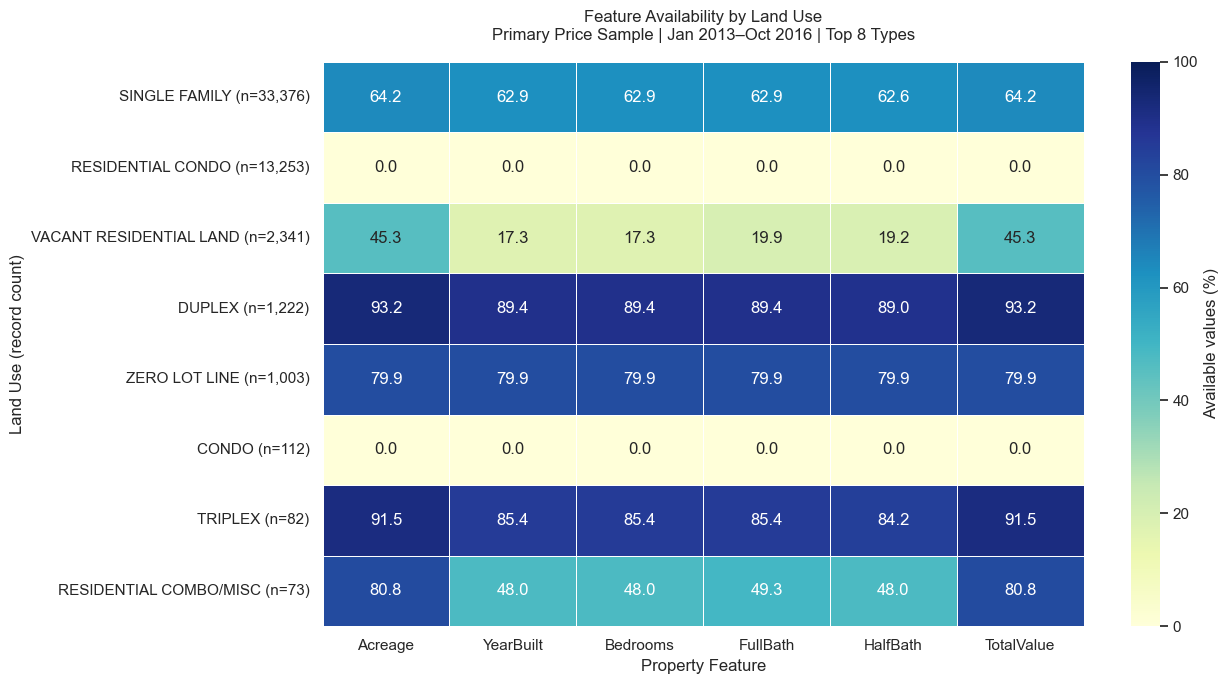

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")

coverage_plot = coverage_price[feature_columns].astype(float)

row_labels = [
    f"{landuse} (n={int(coverage_price.loc[landuse, 'Records']):,})"
    for landuse in coverage_plot.index
]

fig, ax = plt.subplots(figsize=(13, 7))

sns.heatmap(
    coverage_plot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    yticklabels=row_labels,
    cbar_kws={"label": "Available values (%)"},
    ax=ax
)

ax.set_title(
    "Feature Availability by Land Use\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Top 8 Types",
    pad=16
)
ax.set_xlabel("Property Feature")
ax.set_ylabel("Land Use (record count)")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

In [17]:
sf_availability = df_price.loc[
    df_price["LandUse"].eq("SINGLE FAMILY"),
    ["SalePrice", "Bedrooms"]
].copy()

sf_availability["Bedrooms_Status"] = np.where(
    sf_availability["Bedrooms"].notna(),
    "Available",
    "Missing"
)

availability_summary = (
    sf_availability.groupby("Bedrooms_Status")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Mean="mean",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
)

display(availability_summary.round(2))

,Records,Median,Mean,Q1,Q3
Bedrooms_Status,,,,,
Available,20981,193000.0,281585.07,130000.0,330000.0
Missing,12395,224900.0,255713.20,172000.0,295000.0


In [18]:
sf_year_check = df_price.loc[
    df_price["LandUse"].eq("SINGLE FAMILY"),
    ["SaleYear", "Bedrooms", "SalePrice"]
].copy()

sf_year_check["Bedrooms_Available"] = sf_year_check["Bedrooms"].notna()

year_availability = (
    sf_year_check.groupby("SaleYear")
    .agg(
        Records=("SalePrice", "size"),
        Bedrooms_Available_Percent=("Bedrooms_Available", "mean")
    )
)

year_availability["Bedrooms_Available_Percent"] *= 100

year_medians = sf_year_check.pivot_table(
    index="SaleYear",
    columns="Bedrooms_Available",
    values="SalePrice",
    aggfunc="median"
).rename(columns={
    False: "Median_Missing",
    True: "Median_Available"
})

display(year_availability.join(year_medians).round(2))

,Records,Bedrooms_Available_Percent,Median_Missing,Median_Available
SaleYear,,,,
2013,6980,64.61,205000.0,166950.0
2014,8379,63.64,215000.0,180000.0
2015,9685,61.28,225815.5,193000.0
2016,8332,62.46,245923.0,224900.0


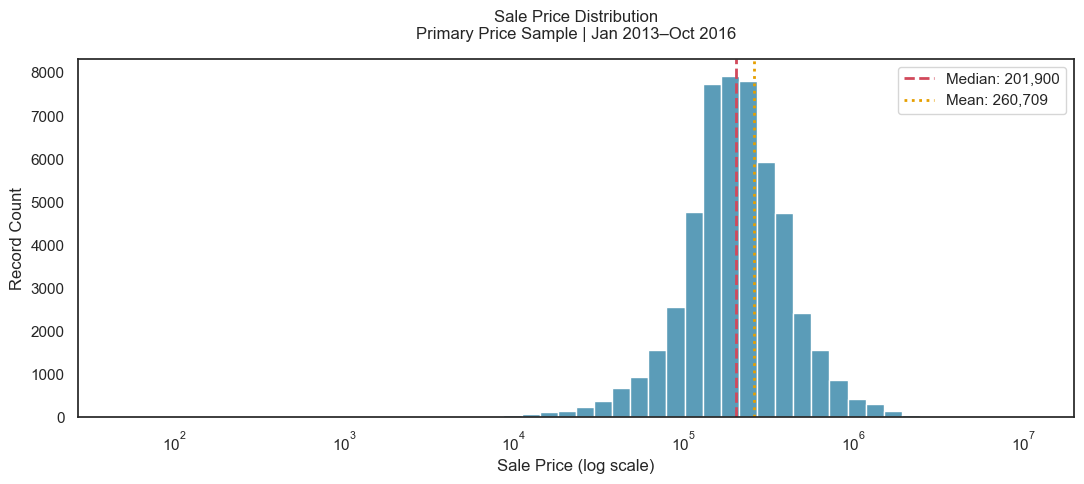

Records plotted: 51,605
Non-positive prices: 0


In [19]:
prices = df_price["SalePrice"].dropna()
prices = prices[prices > 0]

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    x=prices,
    bins=50,
    log_scale=True,
    color="#247BA0",
    edgecolor="white",
    ax=ax
)

ax.axvline(
    prices.median(),
    color="#D1495B",
    linestyle="--",
    linewidth=2,
    label=f"Median: {prices.median():,.0f}"
)

ax.axvline(
    prices.mean(),
    color="#E69F00",
    linestyle=":",
    linewidth=2,
    label=f"Mean: {prices.mean():,.0f}"
)

ax.set_title(
    "Sale Price Distribution\nPrimary Price Sample | Jan 2013–Oct 2016",
    pad=14
)
ax.set_xlabel("Sale Price (log scale)")
ax.set_ylabel("Record Count")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Records plotted: {len(prices):,}")
print(f"Non-positive prices: {df_price['SalePrice'].le(0).sum():,}")

In [20]:
price_percentiles = df_price["SalePrice"].quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]
)

price_percentiles.index = [
    "Minimum", "P01", "P05", "P25", "Median",
    "P75", "P95", "P99", "Maximum"
]

display(price_percentiles.rename("SalePrice").to_frame().round(2))

,SalePrice
Minimum,50.0
P01,25000.0
P05,60000.0
P25,135000.0
Median,201900.0
P75,313000.0
P95,634612.6
P99,1225000.0
Maximum,10750000.0


In [21]:
review_columns = [
    "UniqueID", "ParcelID", "LandUse", "PropertyCity",
    "SaleDate", "SalePrice", "SoldAsVacant", "LegalReference"
]

print("Lowest 5 sale prices")
display(
    df_price.nsmallest(5, "SalePrice")[review_columns]
)

print("Highest 5 sale prices")
display(
    df_price.nlargest(5, "SalePrice")[review_columns]
)

Lowest 5 sale prices


,UniqueID,ParcelID,LandUse,PropertyCity,SaleDate,SalePrice,SoldAsVacant,LegalReference
12698,1168,081 11 0 466.00,VACANT RESIDENTIAL LAND,NASHVILLE,2013-03-15,50,No,20130320-0027369
1344,245,041 11 0 011.00,SINGLE FAMILY,NASHVILLE,2013-01-04,100,No,20130129-0009438
7514,8894,070 05 0 031.00,SINGLE FAMILY,NASHVILLE,2013-10-15,100,No,20131016-0108113
18384,13272,091 04 0 050.00,VACANT RESIDENTIAL LAND,NASHVILLE,2014-03-10,500,Yes,20140403-0027813
7560,45277,070 08 0 061.00,VACANT RESIDENTIAL LAND,NASHVILLE,2016-03-22,750,Yes,20160323-0027506


Highest 5 sale prices


,UniqueID,ParcelID,LandUse,PropertyCity,SaleDate,SalePrice,SoldAsVacant,LegalReference
32093,4179,117 07 0 137.00,SINGLE FAMILY,NASHVILLE,2013-06-28,10750000,No,20130701-0067385
36346,1099,130 03 0 122.00,SINGLE FAMILY,NASHVILLE,2013-03-01,7200000,No,20130301-0020968
24128,36420,102 00 0 018.00,FOREST,NASHVILLE,2015-08-06,5200000,Yes,20150806-0078672
42188,54377,144 01 0 005.00,SINGLE FAMILY,NASHVILLE,2016-09-02,5000000,No,20160907-0094170
36625,8707,130 12 0A 011.00,SINGLE FAMILY,NASHVILLE,2013-10-28,4800000,No,20131105-0114664


In [22]:
landuse_price_summary = (
    df_price.groupby("LandUse")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75),
        P95=lambda s: s.quantile(0.95)
    )
    .sort_values("Records", ascending=False)
    .head(8)
)

display(landuse_price_summary.round(2))

,Records,Median,Q1,Q3,P95
LandUse,,,,,
SINGLE FAMILY,33376,209000.0,145000.0,314000.0,667625.00
RESIDENTIAL CONDO,13253,215000.0,138000.0,337400.0,625860.00
VACANT RESIDENTIAL LAND,2341,74110.0,40000.0,225000.0,457074.00
DUPLEX,1222,150000.0,107000.0,265000.0,500000.00
ZERO LOT LINE,1003,104000.0,78450.0,139000.0,271800.00
CONDO,112,199000.0,155750.0,301250.0,404427.35
TRIPLEX,82,160000.0,111750.0,317875.0,598675.00
RESIDENTIAL COMBO/MISC,73,127000.0,58000.0,275000.0,735000.00


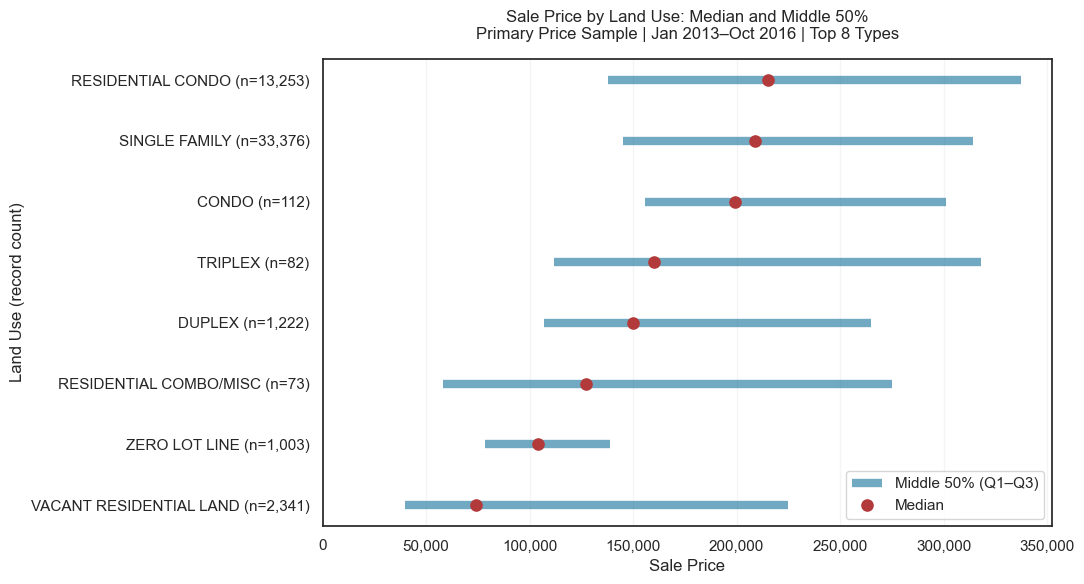

In [23]:
type_plot = landuse_price_summary.sort_values("Median")
positions = np.arange(len(type_plot))

fig, ax = plt.subplots(figsize=(11, 6))

ax.hlines(
    y=positions,
    xmin=type_plot["Q1"],
    xmax=type_plot["Q3"],
    color="#247BA0",
    linewidth=6,
    alpha=0.65,
    label="Middle 50% (Q1–Q3)"
)

ax.scatter(
    type_plot["Median"],
    positions,
    color="#B33A3A",
    s=65,
    zorder=3,
    label="Median"
)

ax.set_yticks(positions)
ax.set_yticklabels([
    f"{name} (n={int(row['Records']):,})"
    for name, row in type_plot.iterrows()
])

ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)

ax.set_title(
    "Sale Price by Land Use: Median and Middle 50%\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Top 8 Types",
    pad=14
)
ax.set_xlabel("Sale Price")
ax.set_ylabel("Land Use (record count)")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [24]:
city_price_summary = (
    df_price.groupby("PropertyCity")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
    .sort_values("Records", ascending=False)
)

city_price_summary["Meets_Minimum_N"] = (
    city_price_summary["Records"] >= 30
)

display(city_price_summary.round(2))

print(
    "Records with missing PropertyCity:",
    df_price["PropertyCity"].isna().sum()
)

,Records,Median,Q1,Q3,Meets_Minimum_N
PropertyCity,,,,,
NASHVILLE,37301,227500.0,142500.0,350000.0,True
ANTIOCH,5255,151000.0,122000.0,189502.5,True
HERMITAGE,3019,173000.0,136000.0,236000.0,True
MADISON,1802,120500.0,80125.0,162375.0,True
BRENTWOOD,1620,278572.5,214430.0,359900.0,True
OLD HICKORY,1323,150000.0,114700.0,206000.0,True
GOODLETTSVILLE,603,157500.0,130000.0,186700.0,True
NOLENSVILLE,438,291484.5,240725.0,335187.5,True
MOUNT JULIET,147,280638.0,250882.5,314262.5,True


Records with missing PropertyCity: 1


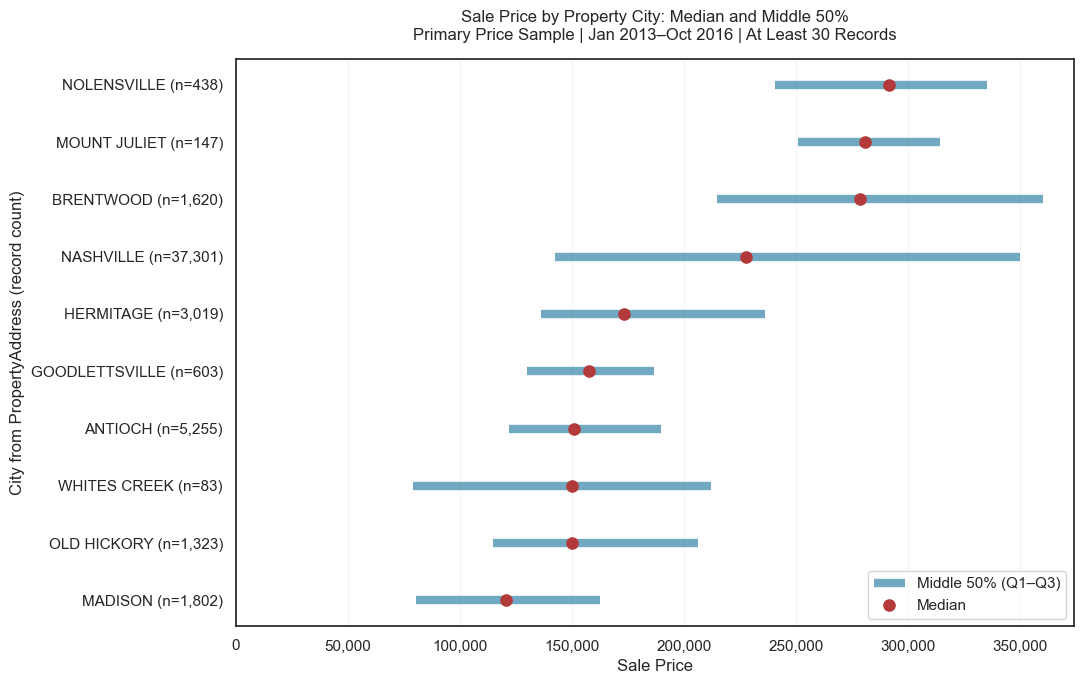

In [25]:
city_plot = (
    city_price_summary.loc[city_price_summary["Meets_Minimum_N"]]
    .sort_values("Median")
)

positions = np.arange(len(city_plot))

fig, ax = plt.subplots(figsize=(11, 7))

ax.hlines(
    positions,
    city_plot["Q1"],
    city_plot["Q3"],
    color="#247BA0",
    linewidth=6,
    alpha=0.65,
    label="Middle 50% (Q1–Q3)"
)

ax.scatter(
    city_plot["Median"],
    positions,
    color="#B33A3A",
    s=65,
    zorder=3,
    label="Median"
)

ax.set_yticks(positions)
ax.set_yticklabels([
    f"{city} (n={int(row['Records']):,})"
    for city, row in city_plot.iterrows()
])

ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)

ax.set_title(
    "Sale Price by Property City: Median and Middle 50%\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | At Least 30 Records",
    pad=14
)
ax.set_xlabel("Sale Price")
ax.set_ylabel("City from PropertyAddress (record count)")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [26]:
sf_city_summary = (
    df_price.loc[df_price["LandUse"].eq("SINGLE FAMILY")]
    .groupby("PropertyCity")["SalePrice"]
    .agg(
        SF_Records="size",
        SF_Median="median",
        SF_Q1=lambda s: s.quantile(0.25),
        SF_Q3=lambda s: s.quantile(0.75)
    )
)

city_comparison = (
    city_price_summary[["Records", "Median"]]
    .rename(columns={
        "Records": "All_Types_Records",
        "Median": "All_Types_Median"
    })
    .join(sf_city_summary)
)

city_comparison = city_comparison.loc[
    city_comparison["SF_Records"].ge(30)
].copy()

city_comparison["SF_Share_Percent"] = (
    city_comparison["SF_Records"]
    / city_comparison["All_Types_Records"] * 100
)

display(
    city_comparison.sort_values(
        "SF_Median", ascending=False
    ).round(2)
)

,All_Types_Records,All_Types_Median,SF_Records,SF_Median,SF_Q1,SF_Q3,SF_Share_Percent
PropertyCity,,,,,,,
BRENTWOOD,1620,278572.5,974.0,329450.0,267700.00,390000.0,60.12
NOLENSVILLE,438,291484.5,344.0,306600.0,271856.25,347625.0,78.54
MOUNT JULIET,147,280638.0,131.0,283169.0,263845.00,319806.0,89.12
NASHVILLE,37301,227500.0,22850.0,231500.0,151000.00,350404.5,61.26
HERMITAGE,3019,173000.0,2123.0,194040.0,150000.00,253750.0,70.32
WHITES CREEK,83,150000.0,61.0,172500.0,135000.00,215000.0,73.49
ANTIOCH,5255,151000.0,3993.0,165990.0,137500.00,200000.0,75.98
GOODLETTSVILLE,603,157500.0,500.0,164400.0,135000.00,193750.0,82.92
OLD HICKORY,1323,150000.0,1118.0,156250.0,124900.00,216750.0,84.50


In [27]:
sf_city_year = (
    df_price.loc[
        df_price["LandUse"].eq("SINGLE FAMILY")
        & df_price["SaleMonth"].between(1, 10)
    ]
    .groupby(["PropertyCity", "SaleYear"])["SalePrice"]
    .agg(Records="size", Median="median")
    .reset_index()
)

sf_city_year["Median_For_Comparison"] = (
    sf_city_year["Median"].where(sf_city_year["Records"].ge(30))
)

city_order = city_comparison.sort_values(
    "SF_Median", ascending=False
).index

sf_city_year_counts = sf_city_year.pivot(
    index="PropertyCity", columns="SaleYear", values="Records"
).reindex(city_order).fillna(0).astype(int)

sf_city_year_medians = sf_city_year.pivot(
    index="PropertyCity",
    columns="SaleYear",
    values="Median_For_Comparison"
).reindex(city_order)

print("Record counts | SINGLE FAMILY | Jan–Oct")
display(sf_city_year_counts)

print("Median sale prices | At least 30 records per city-year")
display(sf_city_year_medians.round(2))

Record counts | SINGLE FAMILY | Jan–Oct


SaleYear,2013,2014,2015,2016
PropertyCity,,,,
BRENTWOOD,181,204,263,220
NOLENSVILLE,33,62,88,114
MOUNT JULIET,11,32,41,19
NASHVILLE,4151,4841,5639,5505
HERMITAGE,364,482,479,548
WHITES CREEK,8,13,14,18
ANTIOCH,613,812,1009,1080
GOODLETTSVILLE,88,115,117,127
OLD HICKORY,175,209,281,325


Median sale prices | At least 30 records per city-year


SaleYear,2013,2014,2015,2016
PropertyCity,,,,
BRENTWOOD,325000.0,300000.0,350000.0,364950.0
NOLENSVILLE,319900.0,293484.5,299781.5,317750.0
MOUNT JULIET,NaN,279322.5,283169.0,NaN
NASHVILLE,208500.0,219636.0,231600.0,260000.0
HERMITAGE,165000.0,188430.0,200500.0,220000.0
WHITES CREEK,NaN,NaN,NaN,NaN
ANTIOCH,143600.0,152925.0,171000.0,185450.0
GOODLETTSVILLE,150000.0,156500.0,165000.0,185000.0
OLD HICKORY,136000.0,137000.0,155000.0,181000.0


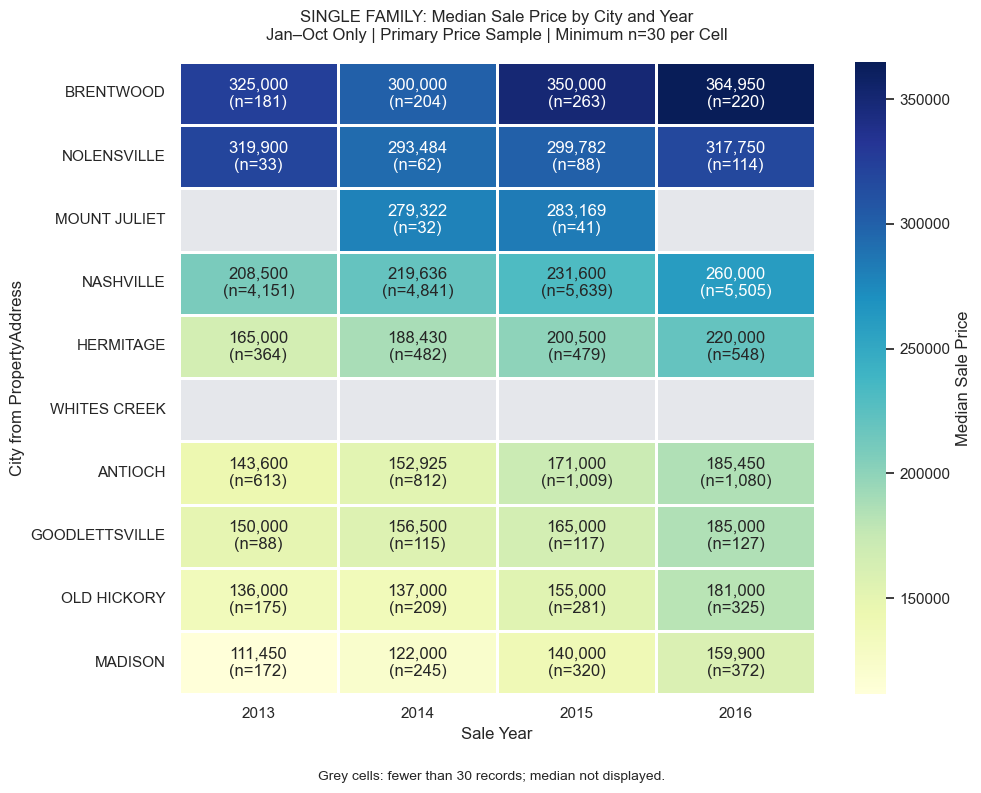

In [28]:
heatmap_values = sf_city_year_medians.copy()

heatmap_labels = pd.DataFrame(
    "",
    index=heatmap_values.index,
    columns=heatmap_values.columns
)

for city in heatmap_values.index:
    for year in heatmap_values.columns:
        value = heatmap_values.loc[city, year]
        count = sf_city_year_counts.loc[city, year]

        if pd.notna(value):
            heatmap_labels.loc[city, year] = (
                f"{value:,.0f}\n(n={count:,})"
            )

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#E5E7EB")

sns.heatmap(
    heatmap_values,
    mask=heatmap_values.isna(),
    annot=heatmap_labels,
    fmt="",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Median Sale Price"},
    ax=ax
)

ax.set_title(
    "SINGLE FAMILY: Median Sale Price by City and Year\n"
    "Jan–Oct Only | Primary Price Sample | Minimum n=30 per Cell",
    pad=16
)
ax.set_xlabel("Sale Year")
ax.set_ylabel("City from PropertyAddress")
ax.tick_params(axis="y", rotation=0)

fig.text(
    0.5, 0.015,
    "Grey cells: fewer than 30 records; median not displayed.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [29]:
sf_bedrooms = df_price.loc[
    df_price["LandUse"].eq("SINGLE FAMILY")
    & df_price["Bedrooms"].notna()
].copy()

bedroom_summary = (
    sf_bedrooms.groupby("Bedrooms")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
    .sort_index()
)

bedroom_summary["Meets_Minimum_N"] = (
    bedroom_summary["Records"] >= 30
)

display(bedroom_summary.round(2))

print("Records with available Bedrooms:", len(sf_bedrooms))

,Records,Median,Q1,Q3,Meets_Minimum_N
Bedrooms,,,,,
0,3,365000.0,273500.0,412500.0,False
1,73,123500.0,65500.0,199000.0,True
2,4359,149000.0,100000.0,222250.0,True
3,11857,179000.0,130000.0,286500.0,True
4,3801,345000.0,198000.0,569000.0,True
5,739,585000.0,340000.0,1112500.0,True
6,118,757500.0,420825.0,1422500.0,True
7,23,725000.0,426005.0,1436250.0,False
8,4,635000.0,511225.0,850000.0,False


Records with available Bedrooms: 20981


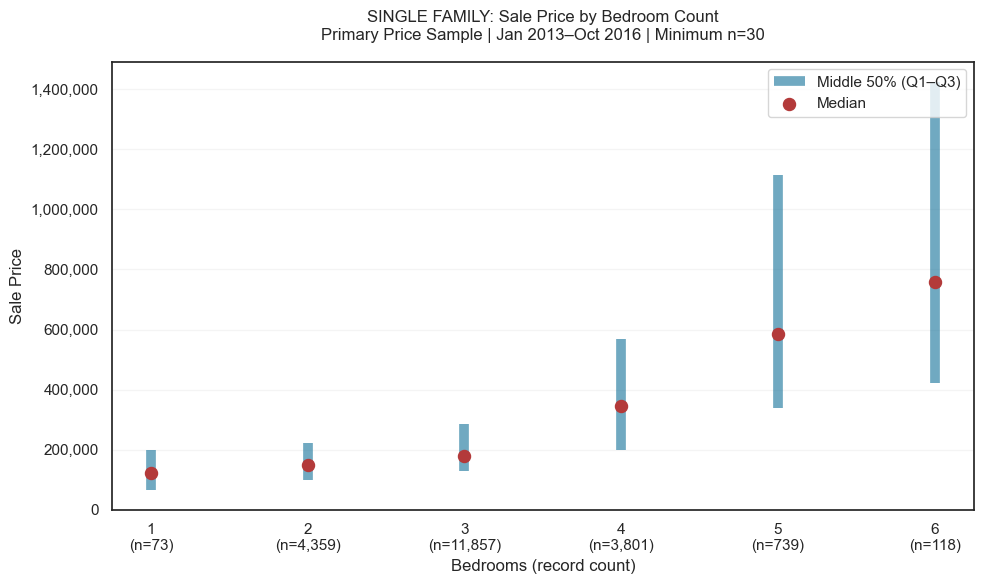

In [30]:
bedroom_plot = bedroom_summary.loc[
    bedroom_summary["Meets_Minimum_N"]
].copy()

x = bedroom_plot.index.to_numpy(dtype=int)

fig, ax = plt.subplots(figsize=(10, 6))

ax.vlines(
    x,
    bedroom_plot["Q1"],
    bedroom_plot["Q3"],
    color="#247BA0",
    linewidth=7,
    alpha=0.65,
    label="Middle 50% (Q1–Q3)"
)

ax.scatter(
    x,
    bedroom_plot["Median"],
    color="#B33A3A",
    s=75,
    zorder=3,
    label="Median"
)

ax.set_xticks(x)
ax.set_xticklabels([
    f"{int(bedrooms)}\n(n={int(row['Records']):,})"
    for bedrooms, row in bedroom_plot.iterrows()
])

ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)

ax.set_title(
    "SINGLE FAMILY: Sale Price by Bedroom Count\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Minimum n=30",
    pad=16
)
ax.set_xlabel("Bedrooms (record count)")
ax.set_ylabel("Sale Price")
ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
bedroom_city_year = (
    sf_bedrooms.loc[
        sf_bedrooms["Bedrooms"].isin([3, 4])
        & sf_bedrooms["SaleMonth"].between(1, 10)
    ]
    .groupby(["PropertyCity", "SaleYear", "Bedrooms"])["SalePrice"]
    .agg(Records="size", Median="median")
)

counts_34 = bedroom_city_year["Records"].unstack(
    "Bedrooms"
).reindex(columns=[3, 4])

medians_34 = bedroom_city_year["Median"].unstack(
    "Bedrooms"
).reindex(columns=[3, 4])

comparison_34 = (
    counts_34.rename(columns={3: "N_3BR", 4: "N_4BR"})
    .join(
        medians_34.rename(columns={
            3: "Median_3BR",
            4: "Median_4BR"
        })
    )
)

comparison_34 = comparison_34.loc[
    comparison_34["N_3BR"].ge(30)
    & comparison_34["N_4BR"].ge(30)
].copy()

comparison_34["Median_Gap_Percent"] = (
    comparison_34["Median_4BR"]
    / comparison_34["Median_3BR"] - 1
) * 100

display(comparison_34.round(2))
print("Eligible city-year comparisons:", len(comparison_34))

Bedrooms                N_3BR  N_4BR  Median_3BR  Median_4BR  \
PropertyCity SaleYear                                          
HERMITAGE    2014       124.0   35.0    137000.0    195000.0   
             2015       148.0   38.0    149250.0    183750.0   
             2016       159.0   37.0    167000.0    184632.0   
MADISON      2014       115.0   31.0    125000.0    159900.0   
NASHVILLE    2013      1563.0  631.0    180000.0    319424.0   
             2014      1828.0  748.0    192700.0    375750.0   
             2015      2140.0  762.0    220000.0    400000.0   
             2016      2157.0  737.0    249900.0    425000.0   

Bedrooms               Median_Gap_Percent  
PropertyCity SaleYear                      
HERMITAGE    2014                   42.34  
             2015                   23.12  
             2016                   10.56  
MADISON      2014                   27.92  
NASHVILLE    2013                   77.46  
             2014                   94.99  
             2015                   81.82  
             2016                   70.07

Eligible city-year comparisons: 8


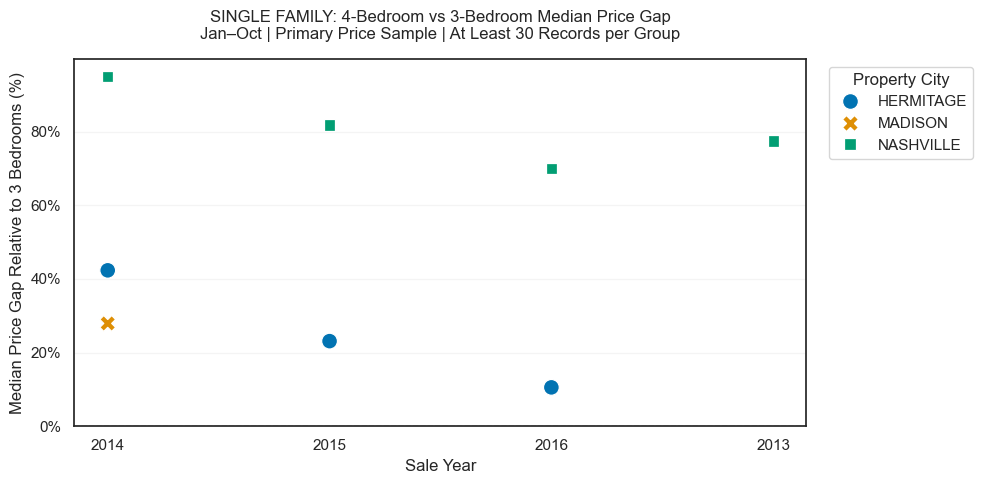

In [32]:
gap_plot = comparison_34.reset_index()
gap_plot["SaleYear"] = gap_plot["SaleYear"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=gap_plot,
    x="SaleYear",
    y="Median_Gap_Percent",
    hue="PropertyCity",
    style="PropertyCity",
    palette="colorblind",
    s=130,
    ax=ax
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)

ax.set_title(
    "SINGLE FAMILY: 4-Bedroom vs 3-Bedroom Median Price Gap\n"
    "Jan–Oct | Primary Price Sample | At Least 30 Records per Group",
    pad=14
)
ax.set_xlabel("Sale Year")
ax.set_ylabel("Median Price Gap Relative to 3 Bedrooms (%)")
ax.grid(axis="y", alpha=0.2)
ax.legend(title="Property City", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

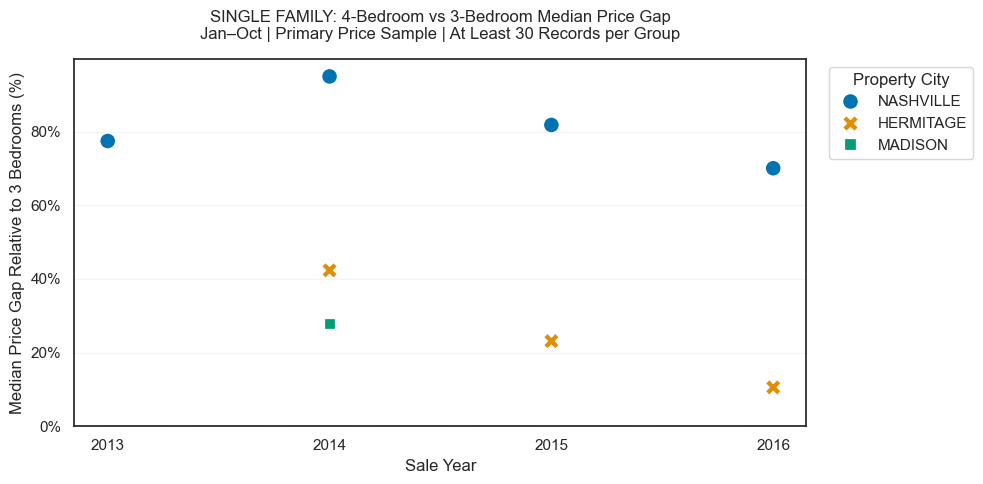

In [33]:
gap_plot = comparison_34.reset_index()
gap_plot["SaleYear"] = gap_plot["SaleYear"].astype(int)
gap_plot = gap_plot.sort_values(["SaleYear", "PropertyCity"])

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=gap_plot,
    x="SaleYear",
    y="Median_Gap_Percent",
    hue="PropertyCity",
    style="PropertyCity",
    palette="colorblind",
    s=130,
    ax=ax
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks([2013, 2014, 2015, 2016])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0f}%")
)

ax.set_title(
    "SINGLE FAMILY: 4-Bedroom vs 3-Bedroom Median Price Gap\n"
    "Jan–Oct | Primary Price Sample | At Least 30 Records per Group",
    pad=14
)
ax.set_xlabel("Sale Year")
ax.set_ylabel("Median Price Gap Relative to 3 Bedrooms (%)")
ax.grid(axis="y", alpha=0.2)
ax.legend(
    title="Property City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [34]:
sf_properties = df_price.loc[
    df_price["LandUse"].eq("SINGLE FAMILY")
].copy()

bath_summaries = {}

for column in ["FullBath", "HalfBath"]:
    summary = (
        sf_properties.groupby(column)["SalePrice"]
        .agg(
            Records="size",
            Median="median",
            Q1=lambda s: s.quantile(0.25),
            Q3=lambda s: s.quantile(0.75)
        )
        .sort_index()
    )

    summary["Meets_Minimum_N"] = summary["Records"] >= 30
    bath_summaries[column] = summary

    print(column)
    display(summary.round(2))
    print("Missing records:", sf_properties[column].isna().sum())

FullBath


,Records,Median,Q1,Q3,Meets_Minimum_N
FullBath,,,,,
0,11,274900.0,161000.0,412500.0,False
1,8659,144500.0,106000.0,203900.0,True
2,8239,215000.0,146000.0,330000.0,True
3,2956,369949.5,220000.0,575000.0,True
4,727,785000.0,494000.0,1150000.0,True
5,292,1025000.0,611500.0,1450500.0,True
6,72,1440000.0,1050000.0,1859375.0,True
7,15,1750000.0,1072700.0,2500000.0,False
8,5,2400000.0,1335000.0,2450000.0,False


Missing records: 12393
HalfBath


,Records,Median,Q1,Q3,Meets_Minimum_N
HalfBath,,,,,
0,15343,179600.0,125000.0,290950.0,True
1,5242,248000.0,150000.0,417875.0,True
2,276,947601.0,446750.0,1430000.0,True
3,22,1422500.0,906000.0,1868750.0,False


Missing records: 12493


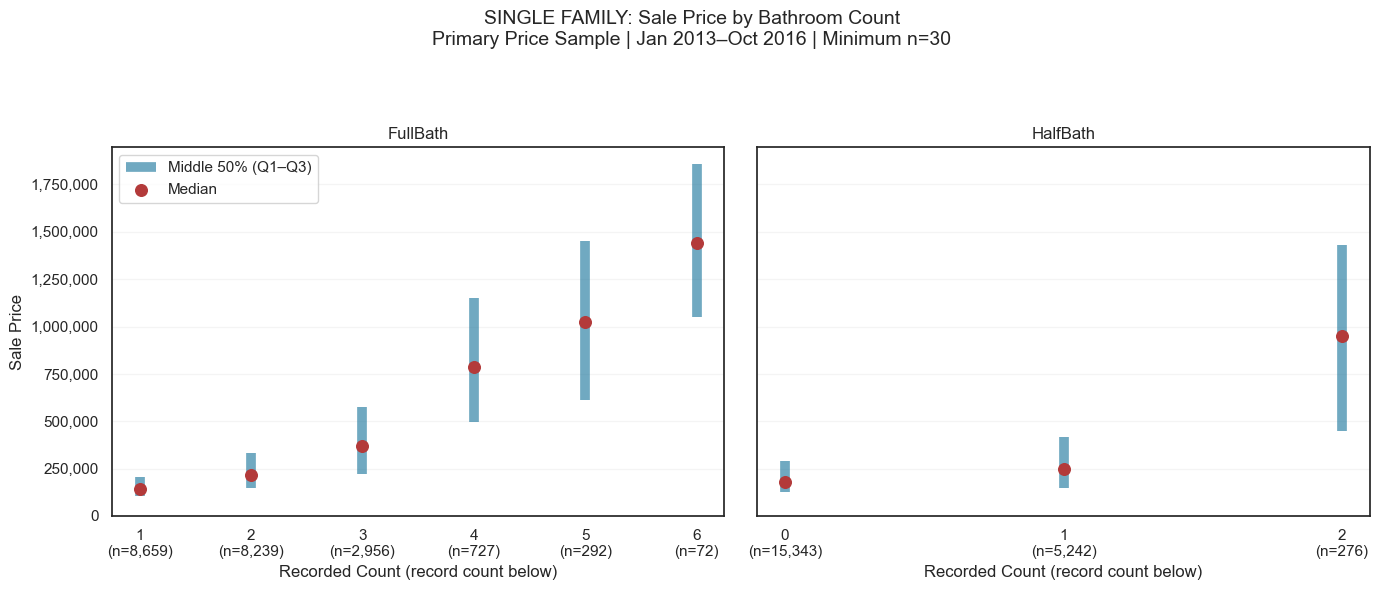

In [35]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6), sharey=True
)

for ax, column in zip(axes, ["FullBath", "HalfBath"]):
    plot_data = bath_summaries[column].loc[
        bath_summaries[column]["Meets_Minimum_N"]
    ]

    x = plot_data.index.to_numpy(dtype=int)

    ax.vlines(
        x, plot_data["Q1"], plot_data["Q3"],
        color="#247BA0", linewidth=7, alpha=0.65,
        label="Middle 50% (Q1–Q3)"
    )

    ax.scatter(
        x, plot_data["Median"],
        color="#B33A3A", s=70, zorder=3,
        label="Median"
    )

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"{int(value)}\n(n={int(row['Records']):,})"
        for value, row in plot_data.iterrows()
    ])

    ax.set_title(column)
    ax.set_xlabel("Recorded Count (record count below)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Sale Price")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)
axes[0].legend(loc="upper left")

fig.suptitle(
    "SINGLE FAMILY: Sale Price by Bathroom Count\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Minimum n=30",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

In [36]:
bed_bath_sample = sf_properties.loc[
    sf_properties["Bedrooms"].isin([3, 4])
    & sf_properties["FullBath"].notna()
    & sf_properties["SaleMonth"].between(1, 10)
].copy()

bed_bath_summary = (
    bed_bath_sample
    .groupby(["FullBath", "Bedrooms"])["SalePrice"]
    .agg(Records="size", Median="median")
)

bed_bath_counts = (
    bed_bath_summary["Records"]
    .unstack("Bedrooms")
    .reindex(columns=[3, 4])
)

bed_bath_medians = (
    bed_bath_summary["Median"]
    .unstack("Bedrooms")
    .reindex(columns=[3, 4])
)

bed_bath_comparison = (
    bed_bath_counts.rename(columns={3: "N_3BR", 4: "N_4BR"})
    .join(
        bed_bath_medians.rename(columns={
            3: "Median_3BR",
            4: "Median_4BR"
        })
    )
)

bed_bath_comparison = bed_bath_comparison.loc[
    bed_bath_comparison["N_3BR"].ge(30)
    & bed_bath_comparison["N_4BR"].ge(30)
].copy()

bed_bath_comparison["Median_Gap_Percent"] = (
    bed_bath_comparison["Median_4BR"]
    / bed_bath_comparison["Median_3BR"] - 1
) * 100

display(bed_bath_comparison.round(2))

Bedrooms,N_3BR,N_4BR,Median_3BR,Median_4BR,Median_Gap_Percent
FullBath,,,,,
1,4143.0,343.0,149000.0,165000.0,10.74
2,5086.0,1307.0,200000.0,270000.0,35.00
3,1115.0,1244.0,304900.0,425000.0,39.39
4,74.0,369.0,652500.0,820000.0,25.67


In [37]:
matched_bath_sample = bed_bath_sample.loc[
    bed_bath_sample["FullBath"].isin(bed_bath_comparison.index)
].copy()

matched_bedroom_summary = (
    matched_bath_sample.groupby("Bedrooms")["SalePrice"]
    .agg(Records="size", Median="median")
)

display(matched_bedroom_summary.round(2))

matched_gap = (
    matched_bedroom_summary.loc[4, "Median"]
    / matched_bedroom_summary.loc[3, "Median"] - 1
) * 100

bath_mix = pd.crosstab(
    matched_bath_sample["Bedrooms"],
    matched_bath_sample["FullBath"],
    normalize="index"
) * 100

print(f"Overall median gap in the same sample: {matched_gap:.2f}%")
print("FullBath distribution within each bedroom group (%)")
display(bath_mix.round(2))

,Records,Median
Bedrooms,,
3,10418,179900.0
4,3263,340000.0


Overall median gap in the same sample: 88.99%
FullBath distribution within each bedroom group (%)


FullBath,1,2,3,4
Bedrooms,,,,
3,39.77,48.82,10.70,0.71
4,10.51,40.06,38.12,11.31


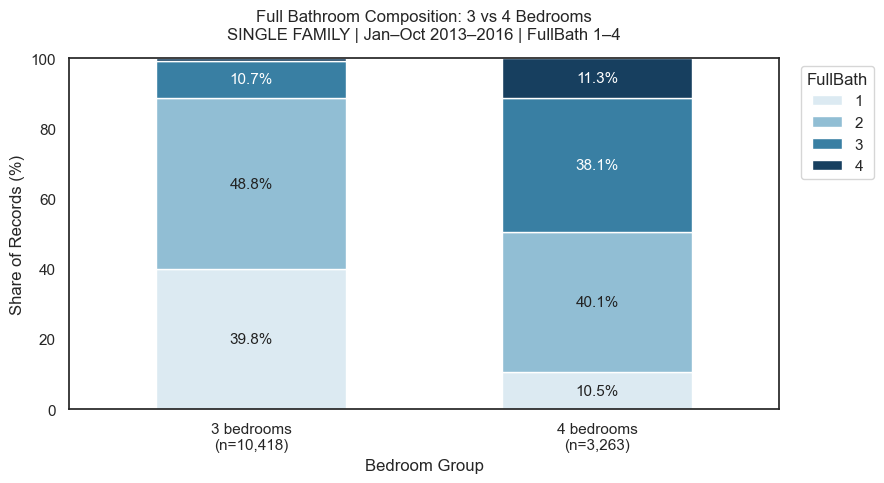

In [38]:
mix_plot = bath_mix.reindex(
    index=[3, 4],
    columns=[1, 2, 3, 4],
    fill_value=0
)

ax = mix_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#DCEAF2", "#91BED4", "#397FA3", "#173F5F"],
    width=0.55,
    edgecolor="white"
)

for container, text_color in zip(
    ax.containers,
    ["#222222", "#222222", "white", "white"]
):
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color=text_color,
        fontsize=11
    )

ax.set_xticklabels([
    f"{bedrooms} bedrooms\n"
    f"(n={int(matched_bedroom_summary.loc[bedrooms, 'Records']):,})"
    for bedrooms in mix_plot.index
], rotation=0)

ax.set_ylim(0, 100)
ax.set_xlabel("Bedroom Group")
ax.set_ylabel("Share of Records (%)")
ax.set_title(
    "Full Bathroom Composition: 3 vs 4 Bedrooms\n"
    "SINGLE FAMILY | Jan–Oct 2013–2016 | FullBath 1–4",
    pad=14
)
ax.legend(
    title="FullBath",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [39]:
year_built = sf_properties["YearBuilt"]
year_difference = sf_properties["SaleYear"] - year_built

year_review = pd.Series({
    "Total records": len(sf_properties),
    "YearBuilt available": int(year_built.notna().sum()),
    "YearBuilt missing": int(year_built.isna().sum()),
    "Built before sale year": int(year_difference.gt(0).sum()),
    "Built in sale year": int(year_difference.eq(0).sum()),
    "Built after sale year": int(year_difference.lt(0).sum())
}, name="Records")

display(year_review.to_frame())

display(
    year_built.describe(
        percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
    ).to_frame("YearBuilt")
)

,Records
Total records,33376
YearBuilt available,20984
YearBuilt missing,12392
Built before sale year,19678
Built in sale year,931
Built after sale year,375


,YearBuilt
count,20984.0
mean,1962.006005
std,25.88672
min,1870.0
1%,1910.0
25%,1947.0
50%,1959.0
75%,1976.0
99%,2016.0
max,2017.0


In [40]:
sf_age = sf_properties.loc[
    sf_properties["YearBuilt"].notna()
    & sf_properties["YearBuilt"].le(sf_properties["SaleYear"])
].copy()

sf_age["AgeAtSale"] = (
    sf_age["SaleYear"] - sf_age["YearBuilt"]
).astype("Int64")

sf_age["AgeGroup"] = pd.cut(
    sf_age["AgeAtSale"].astype(float),
    bins=[-1, 0, 5, 10, 20, 40, 60, 80, np.inf],
    labels=["0", "1–5", "6–10", "11–20", "21–40", "41–60", "61–80", "81+"]
)

age_summary = (
    sf_age.groupby("AgeGroup", observed=True)["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
)

age_summary["Meets_Minimum_N"] = age_summary["Records"].ge(30)

display(age_summary.round(2))
print(f"Records included: {len(sf_age):,}")

,Records,Median,Q1,Q3,Meets_Minimum_N
AgeGroup,,,,,
0,931,383500.0,299900.0,547200.0,True
1–5,426,430450.0,315000.0,746350.0,True
6–10,405,361500.0,198800.0,785000.0,True
11–20,848,177000.0,137000.0,322625.0,True
21–40,2536,158000.0,125000.0,209900.0,True
41–60,7227,175000.0,130000.0,265000.0,True
61–80,5322,195000.0,120000.0,325000.0,True
81+,2914,260450.0,144000.0,424800.0,True


Records included: 20,609


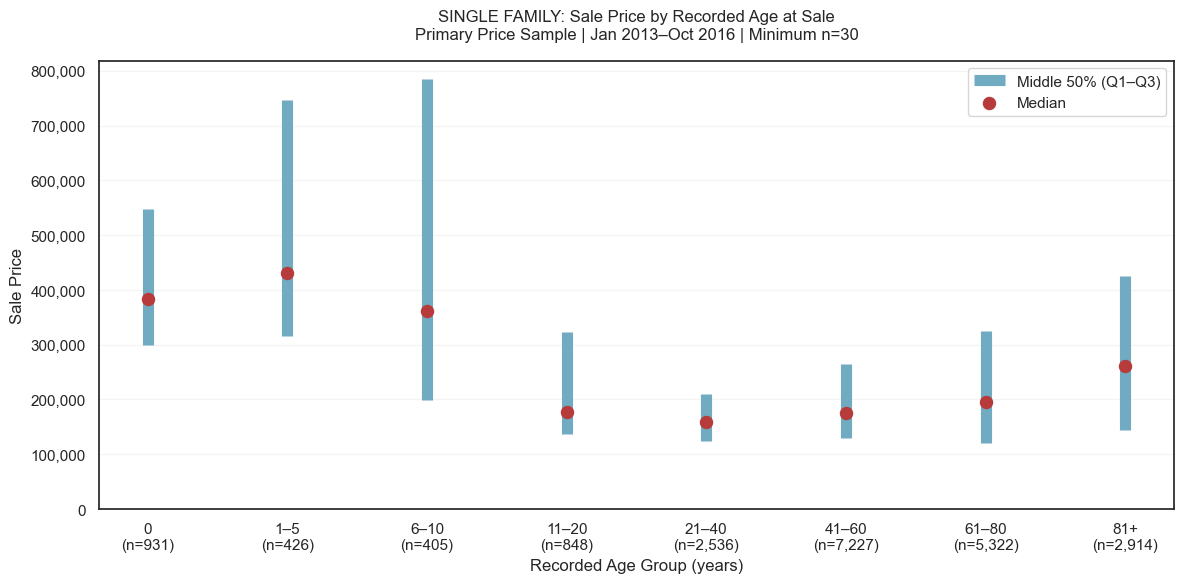

In [41]:
from matplotlib.ticker import StrMethodFormatter

age_plot = age_summary.loc[age_summary["Meets_Minimum_N"]].copy()
x = np.arange(len(age_plot))

fig, ax = plt.subplots(figsize=(12, 6))

ax.vlines(
    x,
    age_plot["Q1"],
    age_plot["Q3"],
    color="#70ABC2",
    linewidth=8,
    label="Middle 50% (Q1–Q3)"
)

ax.scatter(
    x,
    age_plot["Median"],
    color="#B83B3B",
    s=75,
    zorder=3,
    label="Median"
)

ax.set_xticks(x)
ax.set_xticklabels([
    f"{group}\n(n={int(count):,})"
    for group, count in zip(age_plot.index, age_plot["Records"])
])

ax.set_title(
    "SINGLE FAMILY: Sale Price by Recorded Age at Sale\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Minimum n=30",
    pad=16
)
ax.set_xlabel("Recorded Age Group (years)")
ax.set_ylabel("Sale Price")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
age_city_summary = (
    sf_age.groupby(["PropertyCity", "AgeGroup"], observed=True)["SalePrice"]
    .agg(Records="size", Median="median")
)

age_city_counts = (
    age_city_summary["Records"]
    .unstack("AgeGroup")
    .reindex(columns=age_summary.index)
    .fillna(0)
    .astype(int)
)

age_city_medians = (
    age_city_summary["Median"]
    .unstack("AgeGroup")
    .reindex(columns=age_summary.index)
)

eligible_cities = age_city_counts.ge(30).sum(axis=1).ge(2)

age_city_counts = age_city_counts.loc[eligible_cities]
age_city_medians = age_city_medians.loc[eligible_cities].where(
    age_city_counts.ge(30)
)

with pd.option_context("display.max_columns", None, "display.width", 180):
    print("Record counts by city and age group")
    display(age_city_counts)

    print("Median sale prices | Minimum 30 records per city-age group")
    display(age_city_medians.round(0))

Record counts by city and age group


AgeGroup,0,1–5,6–10,11–20,21–40,41–60,61–80,81+
PropertyCity,,,,,,,,
ANTIOCH,10,2,5,177,620,258,3,1
BRENTWOOD,0,1,9,10,94,30,5,5
GOODLETTSVILLE,3,2,4,25,143,191,44,9
HERMITAGE,2,2,6,51,370,382,6,2
MADISON,12,7,17,42,133,460,320,18
NASHVILLE,901,406,341,449,1057,5754,4823,2593
OLD HICKORY,3,6,23,88,111,144,118,285


Median sale prices | Minimum 30 records per city-age group


AgeGroup,0,1–5,6–10,11–20,21–40,41–60,61–80,81+
PropertyCity,,,,,,,,
ANTIOCH,NaN,NaN,NaN,148000.0,133250.0,131250.0,NaN,NaN
BRENTWOOD,NaN,NaN,NaN,NaN,377500.0,542500.0,NaN,NaN
GOODLETTSVILLE,NaN,NaN,NaN,NaN,170000.0,150000.0,141000.0,NaN
HERMITAGE,NaN,NaN,NaN,219900.0,153250.0,144950.0,NaN,NaN
MADISON,NaN,NaN,NaN,130000.0,128500.0,145000.0,103750.0,NaN
NASHVILLE,389900.0,441250.0,405000.0,240000.0,180000.0,190500.0,210000.0,290000.0
OLD HICKORY,NaN,NaN,NaN,154950.0,170000.0,157700.0,112350.0,125000.0


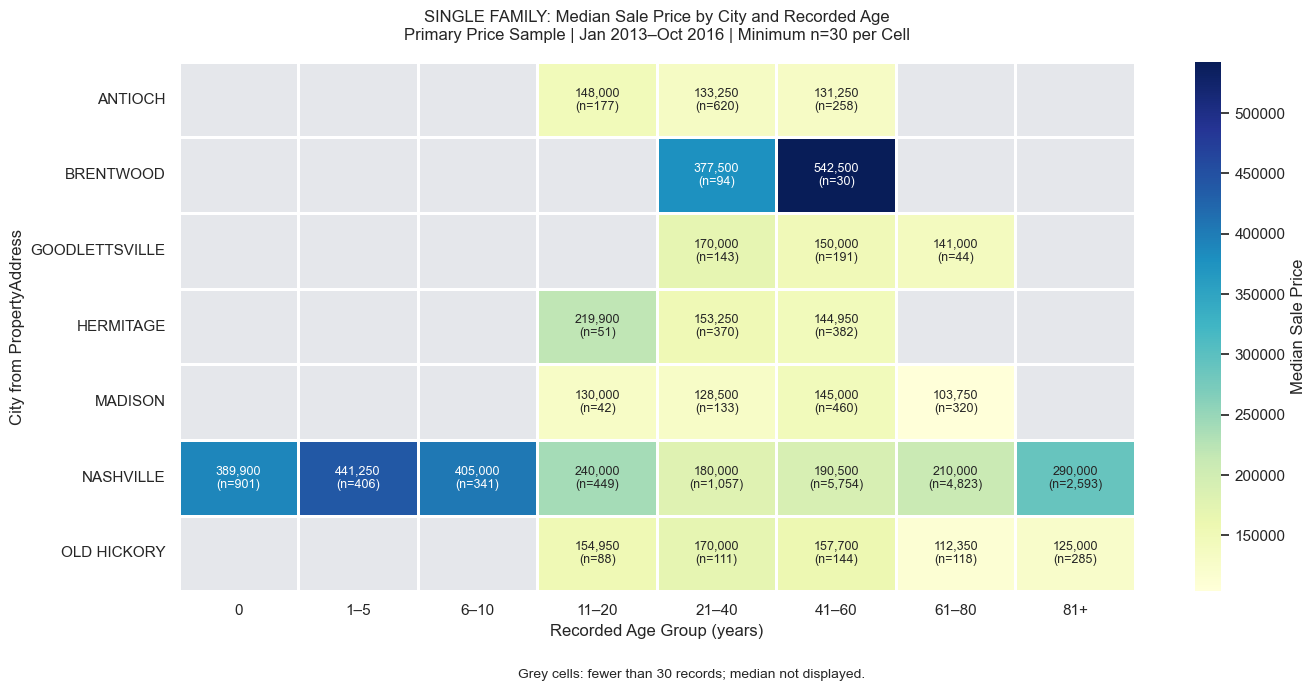

In [43]:
age_annotations = pd.DataFrame(
    "",
    index=age_city_medians.index,
    columns=age_city_medians.columns
)

for city in age_city_medians.index:
    for group in age_city_medians.columns:
        value = age_city_medians.loc[city, group]
        if pd.notna(value):
            count = age_city_counts.loc[city, group]
            age_annotations.loc[city, group] = f"{value:,.0f}\n(n={count:,})"

fig, ax = plt.subplots(figsize=(14, 7))

ax.set_facecolor("#E5E7EB")

sns.heatmap(
    age_city_medians,
    mask=age_city_medians.isna(),
    annot=age_annotations,
    fmt="",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    annot_kws={"fontsize": 9},
    cbar_kws={"label": "Median Sale Price"},
    ax=ax
)

ax.set_title(
    "SINGLE FAMILY: Median Sale Price by City and Recorded Age\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Minimum n=30 per Cell",
    pad=16
)
ax.set_xlabel("Recorded Age Group (years)")
ax.set_ylabel("City from PropertyAddress")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

fig.text(
    0.5, 0.02,
    "Grey cells: fewer than 30 records; median not displayed.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [44]:
acreage = sf_properties["Acreage"]

acreage_review = pd.Series({
    "Total records": len(sf_properties),
    "Acreage available": int(acreage.notna().sum()),
    "Acreage missing": int(acreage.isna().sum()),
    "Zero values": int(acreage.eq(0).sum()),
    "Negative values": int(acreage.lt(0).sum())
}, name="Records")

display(acreage_review.to_frame())

display(
    acreage.describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).to_frame("Acreage")
)

,Records
Total records,33376
Acreage available,21427
Acreage missing,11949
Zero values,0
Negative values,0


,Acreage
count,21427.000000
mean,0.458264
std,0.611782
min,0.040000
1%,0.090000
5%,0.130000
25%,0.200000
50%,0.280000
75%,0.460000
95%,1.210000


In [45]:
import plotly.express as px

sf_acreage = sf_properties.loc[
    sf_properties["Acreage"].gt(0)
    & sf_properties["SalePrice"].gt(0)
].copy()

sf_acreage["City_Display"] = (
    sf_acreage["PropertyCity"].fillna("Unknown").astype(str)
)

sf_acreage["SaleDate_Display"] = (
    sf_acreage["SaleDate"].dt.strftime("%Y-%m-%d")
)

fig = px.scatter(
    sf_acreage,
    x="Acreage",
    y="SalePrice",
    color="City_Display",
    log_x=True,
    log_y=True,
    opacity=0.4,
    render_mode="webgl",
    hover_data={
        "UniqueID": True,
        "SaleDate_Display": True,
        "Acreage": ":.2f",
        "SalePrice": ":,.0f",
        "City_Display": False
    },
    labels={
        "Acreage": "Recorded Acreage (log scale)",
        "SalePrice": "Sale Price (log scale)",
        "City_Display": "Property City",
        "SaleDate_Display": "Sale Date"
    },
    title=(
        "SINGLE FAMILY: Recorded Acreage vs Sale Price"
        "<br><sup>Primary Price Sample | Jan 2013–Oct 2016"
        f" | n={len(sf_acreage):,}</sup>"
    ),
    template="plotly_white",
    height=650
)

fig.update_traces(marker_size=5)
fig.update_layout(legend_title_text="Property City")
fig.show()

print(f"Records plotted: {len(sf_acreage):,}")

Records plotted: 21,427


In [46]:
acreage_corr_rows = [{
    "Scope": "ALL CITIES",
    "Records": len(sf_acreage),
    "Unique_Acreage": sf_acreage["Acreage"].nunique(),
    "Spearman": sf_acreage["Acreage"].corr(
        sf_acreage["SalePrice"], method="spearman"
    )
}]

for city, group in sf_acreage.groupby("City_Display"):
    if (
        len(group) >= 30
        and group["Acreage"].nunique() > 1
        and group["SalePrice"].nunique() > 1
    ):
        acreage_corr_rows.append({
            "Scope": city,
            "Records": len(group),
            "Unique_Acreage": group["Acreage"].nunique(),
            "Spearman": group["Acreage"].corr(
                group["SalePrice"], method="spearman"
            )
        })

acreage_correlations = pd.DataFrame(
    acreage_corr_rows
).set_index("Scope")

display(acreage_correlations.round(3))

,Records,Unique_Acreage,Spearman
Scope,,,
ALL CITIES,21427,400,0.236
ANTIOCH,1079,51,0.187
BRENTWOOD,156,90,0.610
GOODLETTSVILLE,421,125,0.407
HERMITAGE,821,90,0.428
MADISON,1011,143,0.523
NASHVILLE,17132,356,0.243
OLD HICKORY,781,104,0.372


In [47]:
vacant_by_type = (
    df_price.groupby(["LandUse", "SoldAsVacant"])["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
)

vacant_counts = (
    vacant_by_type["Records"]
    .unstack("SoldAsVacant")
    .reindex(columns=["No", "Yes"])
    .fillna(0)
    .astype(int)
)

vacant_counts["Total"] = vacant_counts[["No", "Yes"]].sum(axis=1)
vacant_counts["Both_Groups_30_Plus"] = (
    vacant_counts[["No", "Yes"]].ge(30).all(axis=1)
)

display(vacant_counts.sort_values("Total", ascending=False).head(12))

SoldAsVacant,No,Yes,Total,Both_Groups_30_Plus
LandUse,,,,
SINGLE FAMILY,32993,383,33376,True
RESIDENTIAL CONDO,13213,40,13253,True
VACANT RESIDENTIAL LAND,790,1551,2341,True
DUPLEX,1213,9,1222,False
ZERO LOT LINE,1003,0,1003,False
CONDO,112,0,112,False
TRIPLEX,80,2,82,False
RESIDENTIAL COMBO/MISC,61,12,73,False
QUADPLEX,29,0,29,False


In [48]:
eligible_types = vacant_counts.index[
    vacant_counts["Both_Groups_30_Plus"]
]

vacant_comparison = pd.DataFrame(index=eligible_types)

for status in ["No", "Yes"]:
    status_summary = vacant_by_type.xs(
        status, level="SoldAsVacant"
    ).reindex(eligible_types)

    vacant_comparison[f"N_{status}"] = status_summary["Records"]
    vacant_comparison[f"Median_{status}"] = status_summary["Median"]
    vacant_comparison[f"Q1_{status}"] = status_summary["Q1"]
    vacant_comparison[f"Q3_{status}"] = status_summary["Q3"]

vacant_comparison["Median_Gap_Percent"] = (
    vacant_comparison["Median_Yes"]
    / vacant_comparison["Median_No"]
    - 1
) * 100

display(vacant_comparison.round(2))

,N_No,Median_No,Q1_No,Q3_No,N_Yes,Median_Yes,Q1_Yes,Q3_Yes,Median_Gap_Percent
LandUse,,,,,,,,,
RESIDENTIAL CONDO,13213,215000.0,138000.0,337000.0,40,153140.0,65000.0,371175.0,-28.77
SINGLE FAMILY,32993,210000.0,146500.0,315000.0,383,66893.0,45000.0,137500.0,-68.15
VACANT RESIDENTIAL LAND,790,172054.5,30375.0,300000.0,1551,65000.0,40000.0,125000.0,-62.22


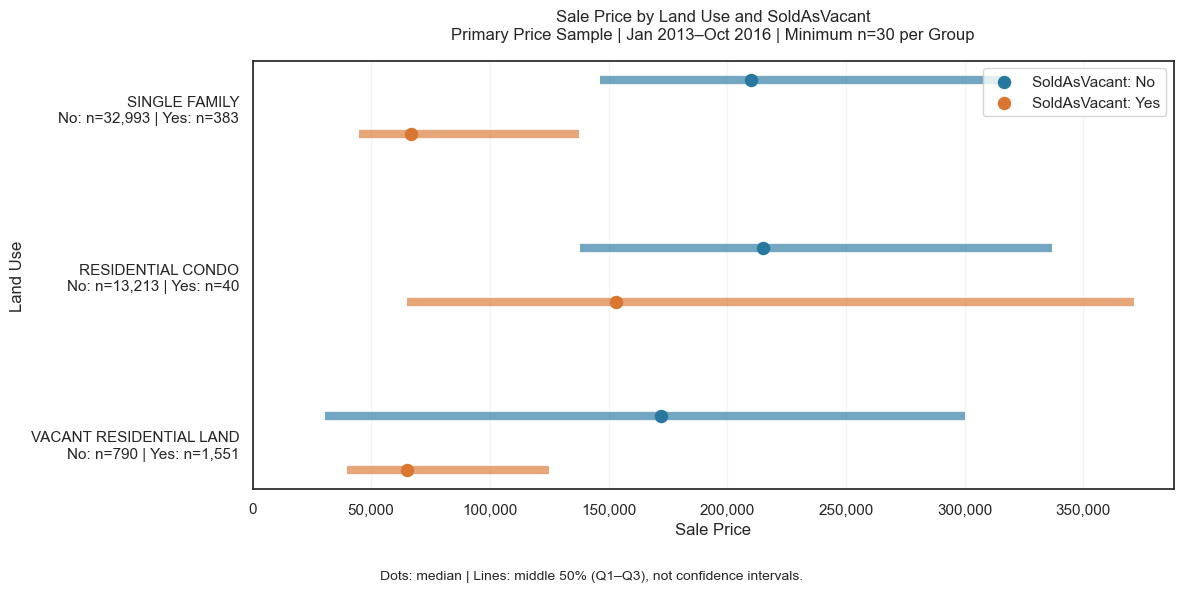

In [49]:
vacant_plot = vacant_comparison.sort_values(
    "N_No", ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(vacant_plot))

for status, offset, color in [
    ("No", -0.16, "#2878A0"),
    ("Yes", 0.16, "#D97732")
]:
    y = positions + offset

    ax.hlines(
        y,
        vacant_plot[f"Q1_{status}"],
        vacant_plot[f"Q3_{status}"],
        color=color,
        linewidth=6,
        alpha=0.65
    )

    ax.scatter(
        vacant_plot[f"Median_{status}"],
        y,
        color=color,
        s=75,
        zorder=3,
        label=f"SoldAsVacant: {status}"
    )

ax.set_yticks(positions)
ax.set_yticklabels([
    f"{landuse}\n"
    f"No: n={int(row['N_No']):,} | Yes: n={int(row['N_Yes']):,}"
    for landuse, row in vacant_plot.iterrows()
])

ax.invert_yaxis()
ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Sale Price")
ax.set_ylabel("Land Use")
ax.set_title(
    "Sale Price by Land Use and SoldAsVacant\n"
    "Primary Price Sample | Jan 2013–Oct 2016 | Minimum n=30 per Group",
    pad=16
)
ax.grid(axis="x", alpha=0.2)
ax.grid(axis="y", visible=False)
ax.legend()

fig.text(
    0.5, 0.02,
    "Dots: median | Lines: middle 50% (Q1–Q3), not confidence intervals.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [50]:
sf_vacant_city_year = (
    sf_properties.loc[sf_properties["SaleMonth"].between(1, 10)]
    .groupby(["PropertyCity", "SaleYear", "SoldAsVacant"])["SalePrice"]
    .agg(Records="size", Median="median")
)

vacant_cy_counts = (
    sf_vacant_city_year["Records"]
    .unstack("SoldAsVacant")
    .reindex(columns=["No", "Yes"])
    .fillna(0)
    .astype(int)
)

vacant_cy_medians = (
    sf_vacant_city_year["Median"]
    .unstack("SoldAsVacant")
    .reindex(columns=["No", "Yes"])
)

vacant_cy_comparison = (
    vacant_cy_counts.rename(columns={"No": "N_No", "Yes": "N_Yes"})
    .join(
        vacant_cy_medians.rename(
            columns={"No": "Median_No", "Yes": "Median_Yes"}
        )
    )
)

vacant_cy_comparison = vacant_cy_comparison.loc[
    vacant_cy_comparison[["N_No", "N_Yes"]].ge(30).all(axis=1)
].copy()

vacant_cy_comparison["Median_Gap_Percent"] = (
    vacant_cy_comparison["Median_Yes"]
    / vacant_cy_comparison["Median_No"]
    - 1
) * 100

display(vacant_cy_comparison.round(2))
print(f"Eligible city-year groups: {len(vacant_cy_comparison)}")

SoldAsVacant           N_No  N_Yes  Median_No  Median_Yes  Median_Gap_Percent
PropertyCity SaleYear                                                        
NASHVILLE    2013      4107     44   210000.0     56739.0              -72.98
             2014      4706    135   221000.0    104500.0              -52.71

Eligible city-year groups: 2


In [51]:
time_types = df_price["LandUse"].value_counts().head(3).index

price_time_sample = df_price.loc[
    df_price["LandUse"].isin(time_types)
    & df_price["SaleMonth"].between(1, 10)
].copy()

annual_type_summary = (
    price_time_sample.groupby(["LandUse", "SaleYear"])["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
)

annual_type_summary["Meets_Minimum_N"] = (
    annual_type_summary["Records"].ge(30)
)

display(annual_type_summary.round(2))

Records    Median        Q1        Q3  \
LandUse                 SaleYear                                          
RESIDENTIAL CONDO       2013         1979  185000.0  127000.0  268617.5   
                        2014         2745  190000.0  129500.0  292000.0   
                        2015         3463  232000.0  142000.0  359900.0   
                        2016         3654  240775.0  155000.0  370000.0   
SINGLE FAMILY           2013         5799  185237.0  126070.0  290950.0   
                        2014         7016  197503.0  134000.0  300000.0   
                        2015         8254  210000.0  150000.0  318500.0   
                        2016         8332  235000.0  170000.0  340900.0   
VACANT RESIDENTIAL LAND 2013          440   58226.5   34500.0  201250.0   
                        2014          489   68000.0   38000.0  240000.0   
                        2015          514   72500.0   45000.0  181500.0   
                        2016          512   75000.0   40000.0  200000.0   

                                  Meets_Minimum_N  
LandUse                 SaleYear                   
RESIDENTIAL CONDO       2013                 True  
                        2014                 True  
                        2015                 True  
                        2016                 True  
SINGLE FAMILY           2013                 True  
                        2014                 True  
                        2015                 True  
                        2016                 True  
VACANT RESIDENTIAL LAND 2013                 True  
                        2014                 True  
                        2015                 True  
                        2016                 True

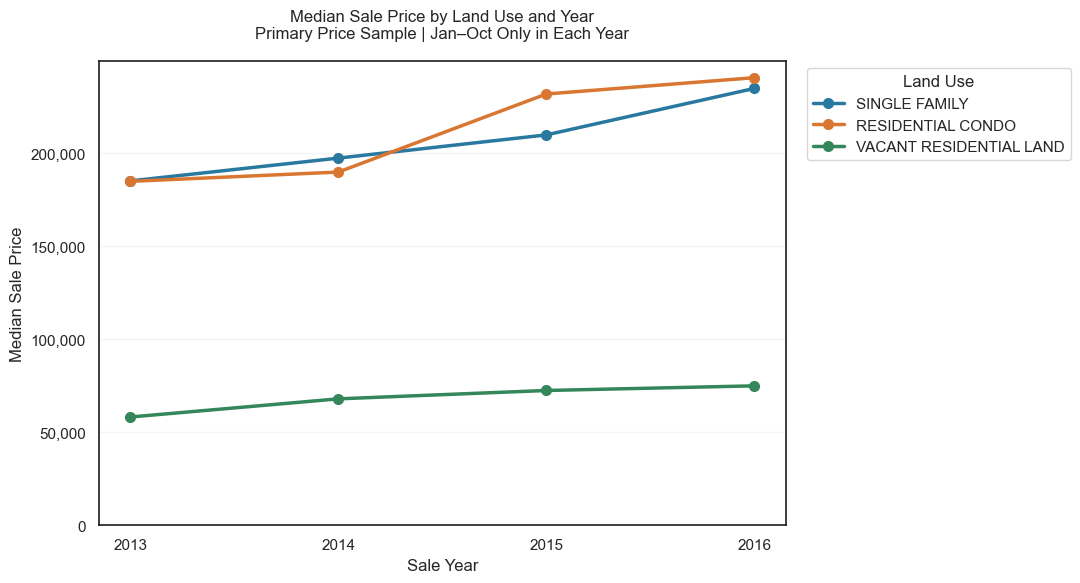

In [52]:
annual_type_plot = annual_type_summary.reset_index()
annual_type_plot["SaleYear"] = annual_type_plot["SaleYear"].astype(int)

annual_type_plot["Median"] = annual_type_plot["Median"].where(
    annual_type_plot["Meets_Minimum_N"]
)

fig, ax = plt.subplots(figsize=(11, 6))

colors = {
    "SINGLE FAMILY": "#2878A0",
    "RESIDENTIAL CONDO": "#D97732",
    "VACANT RESIDENTIAL LAND": "#34875A"
}

for landuse, color in colors.items():
    group = annual_type_plot.loc[
        annual_type_plot["LandUse"].eq(landuse)
    ].sort_values("SaleYear")

    ax.plot(
        group["SaleYear"],
        group["Median"],
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=color,
        label=landuse
    )

ax.set_xticks([2013, 2014, 2015, 2016])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Sale Year")
ax.set_ylabel("Median Sale Price")
ax.set_title(
    "Median Sale Price by Land Use and Year\n"
    "Primary Price Sample | Jan–Oct Only in Each Year",
    pad=16
)
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)
ax.legend(title="Land Use", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [53]:
monthly_index = pd.MultiIndex.from_product(
    [
        time_types,
        pd.period_range("2013-01", "2016-10", freq="M")
    ],
    names=["LandUse", "SaleYearMonth"]
)

monthly_type_summary = (
    df_price.loc[df_price["LandUse"].isin(time_types)]
    .groupby(["LandUse", "SaleYearMonth"])["SalePrice"]
    .agg(Records="size", Median="median")
    .reindex(monthly_index)
)

monthly_type_summary["Records"] = (
    monthly_type_summary["Records"].fillna(0).astype(int)
)

monthly_type_summary["Meets_Minimum_N"] = (
    monthly_type_summary["Records"].ge(30)
)

monthly_coverage = (
    monthly_type_summary.groupby(level="LandUse")
    .agg(
        Months=("Records", "size"),
        Minimum_Monthly_Records=("Records", "min"),
        Median_Monthly_Records=("Records", "median"),
        Months_30_Plus=("Meets_Minimum_N", "sum")
    )
)

display(monthly_coverage)

display(
    monthly_type_summary.loc[
        ~monthly_type_summary["Meets_Minimum_N"],
        ["Records"]
    ]
)

,Months,Minimum_Monthly_Records,Median_Monthly_Records,Months_30_Plus
LandUse,,,,
RESIDENTIAL CONDO,46,76,291.0,46
SINGLE FAMILY,46,258,753.5,46
VACANT RESIDENTIAL LAND,46,25,51.0,44


Records
LandUse                 SaleYearMonth         
VACANT RESIDENTIAL LAND 2013-02             25
                        2015-02             25

In [54]:
import plotly.express as px

monthly_plot = monthly_type_summary.reset_index()

monthly_plot["Month"] = (
    monthly_plot["SaleYearMonth"].dt.to_timestamp()
)

monthly_plot["Median_For_Plot"] = monthly_plot["Median"].where(
    monthly_plot["Meets_Minimum_N"]
)

monthly_plot = monthly_plot.sort_values(["LandUse", "Month"])

fig = px.line(
    monthly_plot,
    x="Month",
    y="Median_For_Plot",
    color="LandUse",
    markers=True,
    color_discrete_map={
        "SINGLE FAMILY": "#2878A0",
        "RESIDENTIAL CONDO": "#D97732",
        "VACANT RESIDENTIAL LAND": "#34875A"
    },
    category_orders={
        "LandUse": [
            "SINGLE FAMILY",
            "RESIDENTIAL CONDO",
            "VACANT RESIDENTIAL LAND"
        ]
    },
    custom_data=["Records"],
    labels={
        "Month": "Sale Month",
        "Median_For_Plot": "Median Sale Price",
        "LandUse": "Land Use"
    },
    title=(
        "Monthly Median Sale Price by Land Use"
        "<br><sup>Primary Price Sample | Jan 2013–Oct 2016"
        " | Minimum n=30 per Month and Type</sup>"
    ),
    template="plotly_white",
    height=650
)

fig.update_traces(
    connectgaps=False,
    marker_size=5,
    hovertemplate=(
        "Month: %{x|%b %Y}<br>"
        "Median: %{y:,.0f}<br>"
        "Records: %{customdata[0]:,.0f}"
        "<extra>%{fullData.name}</extra>"
    )
)

fig.update_xaxes(
    dtick="M6",
    tickformat="%b %Y",
    rangeslider_visible=True
)

fig.update_yaxes(tickformat=",.0f", rangemode="tozero")

fig.add_annotation(
    x=0,
    y=-0.32,
    xref="paper",
    yref="paper",
    text="Gaps: VACANT RESIDENTIAL LAND, Feb 2013 and Feb 2015 (n=25 each).",
    showarrow=False,
    xanchor="left"
)

fig.update_layout(margin=dict(b=145))
fig.show()

In [55]:
condo_window = df_price.loc[
    df_price["LandUse"].eq("RESIDENTIAL CONDO")
    & df_price["SaleDate"].between("2014-10-01", "2015-04-30")
].copy()

condo_monthly_review = (
    condo_window.groupby("SaleYearMonth")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
)

condo_city_mix = pd.crosstab(
    condo_window["SaleYearMonth"],
    condo_window["PropertyCity"].fillna("Unknown"),
    normalize="index"
).mul(100)

display(condo_monthly_review.round(2))
display(condo_city_mix.round(1))

,Records,Median,Q1,Q3
SaleYearMonth,,,,
2014-10,312,192950.0,125375.0,319150.0
2014-11,214,189500.0,142900.0,306650.0
2014-12,317,205000.0,140000.0,319506.0
2015-01,304,260500.0,139975.0,458500.0
2015-02,146,261175.0,163567.5,375000.0
2015-03,328,223700.0,136900.0,335475.0
2015-04,349,244500.0,141000.0,355000.0


PropertyCity,ANTIOCH,BRENTWOOD,GOODLETTSVILLE,HERMITAGE,MADISON,NASHVILLE,NOLENSVILLE,OLD HICKORY
SaleYearMonth,,,,,,,,
2014-10,7.4,4.5,0.0,2.2,1.6,84.0,0.0,0.3
2014-11,6.5,3.3,0.0,7.5,0.9,81.8,0.0,0.0
2014-12,5.7,4.4,1.6,4.4,1.6,82.0,0.3,0.0
2015-01,3.0,2.3,0.7,3.9,1.3,87.5,0.3,1.0
2015-02,2.7,1.4,0.0,2.7,2.1,90.4,0.7,0.0
2015-03,6.7,4.3,0.0,2.1,2.4,82.3,1.2,0.9
2015-04,7.2,3.4,0.0,3.4,3.2,81.4,0.9,0.6


In [56]:
condo_nashville_review = (
    condo_window.loc[
        condo_window["PropertyCity"].eq("NASHVILLE")
    ]
    .groupby("SaleYearMonth")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
)

condo_nashville_review["Meets_Minimum_N"] = (
    condo_nashville_review["Records"].ge(30)
)

display(condo_nashville_review.round(2))

,Records,Median,Q1,Q3,Meets_Minimum_N
SaleYearMonth,,,,,
2014-10,262,209700.0,135000.0,353466.25,True
2014-11,175,215001.0,145000.0,340150.00,True
2014-12,260,247000.0,149300.0,370500.00,True
2015-01,266,298099.5,157500.0,524475.00,True
2015-02,132,277350.0,188500.0,391725.00,True
2015-03,270,258450.0,166125.0,352337.75,True
2015-04,284,275000.0,179000.0,405288.75,True


In [57]:
sensitivity_parts = []

for sample_name, sample in [
    ("Including flagged", df_period),
    ("Excluding flagged", df_price)
]:
    summary = (
        sample.loc[
            sample["LandUse"].isin(time_types)
            & sample["SaleMonth"].between(1, 10)
        ]
        .groupby(["LandUse", "SaleYear"])["SalePrice"]
        .agg(Records="size", Median="median")
        .reset_index()
    )

    summary["Sample"] = sample_name
    sensitivity_parts.append(summary)

annual_sensitivity = pd.concat(
    sensitivity_parts, ignore_index=True
)

sensitivity_table = annual_sensitivity.pivot(
    index=["LandUse", "SaleYear"],
    columns="Sample",
    values=["Records", "Median"]
)

display(sensitivity_table.round(2))

Records                    \
Sample                           Excluding flagged Including flagged   
LandUse                 SaleYear                                       
RESIDENTIAL CONDO       2013                1979.0            2001.0   
                        2014                2745.0            2958.0   
                        2015                3463.0            3743.0   
                        2016                3654.0            3781.0   
SINGLE FAMILY           2013                5799.0            5886.0   
                        2014                7016.0            7242.0   
                        2015                8254.0            8437.0   
                        2016                8332.0            8489.0   
VACANT RESIDENTIAL LAND 2013                 440.0             801.0   
                        2014                 489.0            1002.0   
                        2015                 514.0            1338.0   
                        2016                 512.0            1094.0   

                                            Median                    
Sample                           Excluding flagged Including flagged  
LandUse                 SaleYear                                      
RESIDENTIAL CONDO       2013              185000.0          185000.0  
                        2014              190000.0          192000.0  
                        2015              232000.0          243000.0  
                        2016              240775.0          245000.0  
SINGLE FAMILY           2013              185237.0          186500.0  
                        2014              197503.0          198319.5  
                        2015              210000.0          210000.0  
                        2016              235000.0          235000.0  
VACANT RESIDENTIAL LAND 2013               58226.5          149984.0  
                        2014               68000.0          157500.0  
                        2015               72500.0          210000.0  
                        2016               75000.0          124900.0

In [58]:
land_sensitivity = sensitivity_table.xs(
    "VACANT RESIDENTIAL LAND", level="LandUse"
)

land_flag_review = pd.DataFrame({
    "All_Records": land_sensitivity[("Records", "Including flagged")],
    "Unflagged_Records": land_sensitivity[("Records", "Excluding flagged")],
    "Median_Including": land_sensitivity[("Median", "Including flagged")],
    "Median_Excluding": land_sensitivity[("Median", "Excluding flagged")]
})

land_flag_review["Flagged_Records"] = (
    land_flag_review["All_Records"]
    - land_flag_review["Unflagged_Records"]
)

land_flag_review["Flagged_Share_Percent"] = (
    land_flag_review["Flagged_Records"]
    / land_flag_review["All_Records"]
    * 100
)

display(land_flag_review.round(2))

,All_Records,Unflagged_Records,Median_Including,Median_Excluding,Flagged_Records,Flagged_Share_Percent
SaleYear,,,,,,
2013,801.0,440.0,149984.0,58226.5,361.0,45.07
2014,1002.0,489.0,157500.0,68000.0,513.0,51.20
2015,1338.0,514.0,210000.0,72500.0,824.0,61.58
2016,1094.0,512.0,124900.0,75000.0,582.0,53.20


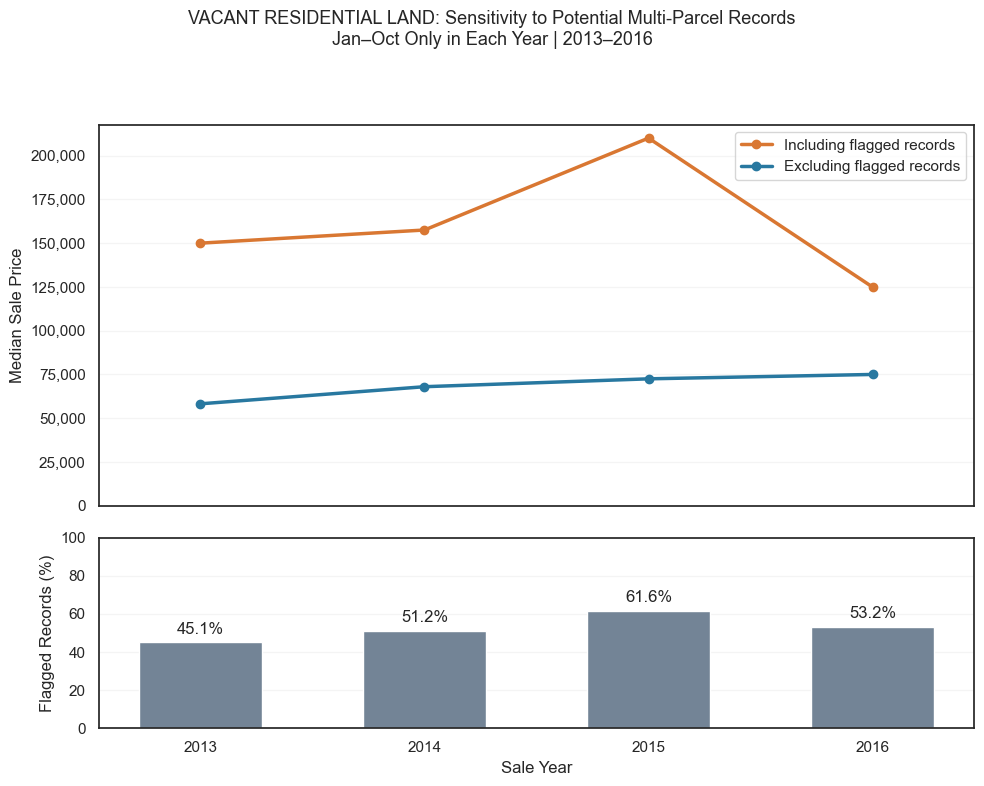

In [59]:
from matplotlib.ticker import StrMethodFormatter

land_plot = land_flag_review.sort_index()
years = land_plot.index.to_numpy(dtype=int)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

for column, label, color in [
    ("Median_Including", "Including flagged records", "#D97732"),
    ("Median_Excluding", "Excluding flagged records", "#2878A0")
]:
    axes[0].plot(
        years,
        land_plot[column],
        marker="o",
        linewidth=2.5,
        color=color,
        label=label
    )

axes[0].set_ylabel("Median Sale Price")
axes[0].set_ylim(bottom=0)
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

bars = axes[1].bar(
    years,
    land_plot["Flagged_Share_Percent"],
    color="#738496",
    width=0.55
)

axes[1].bar_label(bars, fmt="%.1f%%", padding=4)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Flagged Records (%)")
axes[1].set_xlabel("Sale Year")
axes[1].set_xticks(years)
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle(
    "VACANT RESIDENTIAL LAND: Sensitivity to Potential Multi-Parcel Records\n"
    "Jan–Oct Only in Each Year | 2013–2016",
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [60]:
sf_multivariate = sf_properties.copy()

sf_multivariate["AgeAtSale"] = (
    sf_multivariate["SaleYear"] - sf_multivariate["YearBuilt"]
).where(
    sf_multivariate["YearBuilt"].le(sf_multivariate["SaleYear"])
)

correlation_columns = [
    "SalePrice",
    "Bedrooms",
    "FullBath",
    "HalfBath",
    "Acreage",
    "AgeAtSale"
]

correlation_data = sf_multivariate[correlation_columns].astype(float)

spearman_matrix = correlation_data.corr(
    method="spearman",
    min_periods=30
)

available = correlation_data.notna().astype("int64")
pair_counts = available.T.dot(available)

display(spearman_matrix.round(3))
display(pair_counts)

,SalePrice,Bedrooms,FullBath,HalfBath,Acreage,AgeAtSale
SalePrice,1.000,0.408,0.541,0.219,0.236,0.001
Bedrooms,0.408,1.000,0.568,0.231,0.215,-0.213
FullBath,0.541,0.568,1.000,0.015,0.186,-0.266
HalfBath,0.219,0.231,0.015,1.000,0.073,-0.194
Acreage,0.236,0.215,0.186,0.073,1.000,-0.144
AgeAtSale,0.001,-0.213,-0.266,-0.194,-0.144,1.000


,SalePrice,Bedrooms,FullBath,HalfBath,Acreage,AgeAtSale
SalePrice,33376,20981,20983,20883,21427,20609
Bedrooms,20981,20981,20980,20880,20981,20609
FullBath,20983,20980,20983,20883,20983,20608
HalfBath,20883,20880,20883,20883,20883,20517
Acreage,21427,20981,20983,20883,21427,20609
AgeAtSale,20609,20609,20608,20517,20609,20609


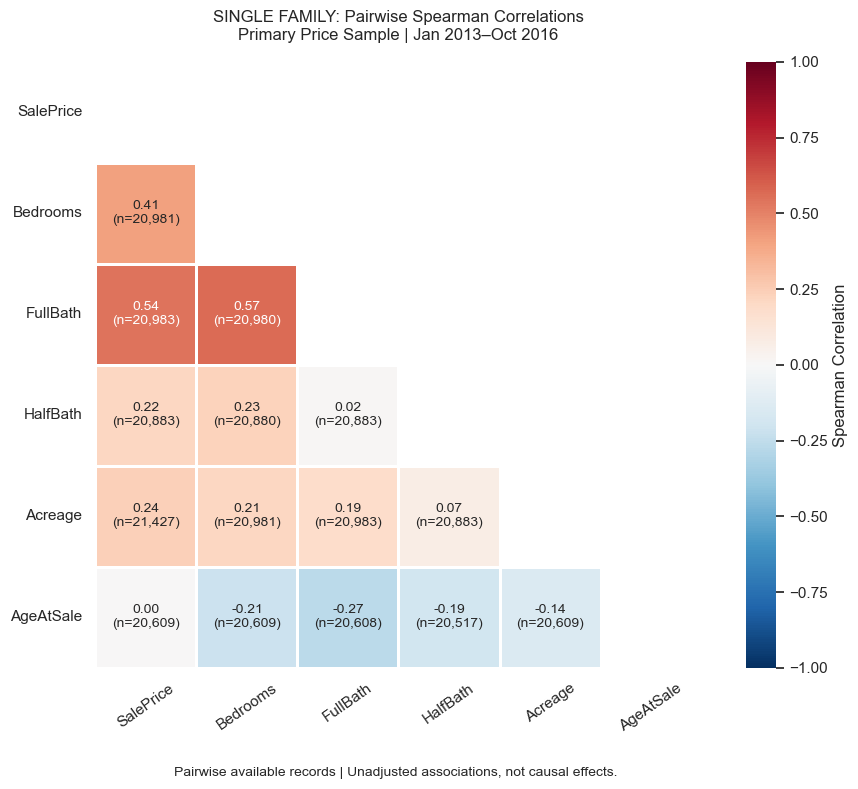

In [61]:
correlation_annotations = pd.DataFrame(
    "",
    index=spearman_matrix.index,
    columns=spearman_matrix.columns
)

for row in spearman_matrix.index:
    for column in spearman_matrix.columns:
        value = spearman_matrix.loc[row, column]
        count = pair_counts.loc[row, column]

        if pd.notna(value):
            correlation_annotations.loc[row, column] = (
                f"{value:.2f}\n(n={count:,})"
            )

mask = np.triu(
    np.ones(spearman_matrix.shape, dtype=bool),
    k=0
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    spearman_matrix,
    mask=mask,
    annot=correlation_annotations,
    fmt="",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=1,
    annot_kws={"fontsize": 10},
    cbar_kws={"label": "Spearman Correlation"},
    ax=ax
)

ax.set_title(
    "SINGLE FAMILY: Pairwise Spearman Correlations\n"
    "Primary Price Sample | Jan 2013–Oct 2016",
    pad=16
)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

fig.text(
    0.5, 0.02,
    "Pairwise available records | Unadjusted associations, not causal effects.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [62]:
model_columns = [
    "SalePrice",
    "Bedrooms",
    "FullBath",
    "HalfBath",
    "Acreage",
    "AgeAtSale",
    "PropertyCity",
    "SaleYear"
]

model_eligible = (
    sf_multivariate[model_columns].notna().all(axis=1)
    & sf_multivariate["SalePrice"].gt(0)
    & sf_multivariate["Acreage"].gt(0)
    & sf_multivariate["AgeAtSale"].ge(0)
).fillna(False)

model_sample = sf_multivariate.loc[model_eligible].copy()

sample_review = sf_multivariate.assign(
    Sample_Status=np.where(model_eligible, "Included", "Excluded")
)

sample_summary = (
    sample_review.groupby("Sample_Status")["SalePrice"]
    .agg(
        Records="size",
        Median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75)
    )
    .reindex(["Included", "Excluded"])
)

sample_summary["Share_Percent"] = (
    sample_summary["Records"] / len(sf_multivariate) * 100
)

city_sample_review = (
    sample_review.assign(Included=model_eligible.astype(int))
    .groupby("PropertyCity", dropna=False)
    .agg(
        All_Records=("SalePrice", "size"),
        Included_Records=("Included", "sum")
    )
)

city_sample_review["Retained_Percent"] = (
    city_sample_review["Included_Records"]
    / city_sample_review["All_Records"]
    * 100
)

city_sample_review = city_sample_review.sort_values(
    "All_Records", ascending=False
)

print("Common sample: inclusion and exclusion")
display(sample_summary.round(2))

print("Common sample: coverage by property city")
display(city_sample_review.round(2))

Common sample: inclusion and exclusion


,Records,Median,Q1,Q3,Share_Percent
Sample_Status,,,,,
Included,20517,193000.0,131297.0,329999.0,61.47
Excluded,12859,224761.0,170000.0,295825.5,38.53


Common sample: coverage by property city


,All_Records,Included_Records,Retained_Percent
PropertyCity,,,
NASHVILLE,22850,16260,71.16
ANTIOCH,3993,1076,26.95
HERMITAGE,2123,821,38.67
MADISON,1271,1008,79.31
OLD HICKORY,1118,751,67.17
BRENTWOOD,974,154,15.81
GOODLETTSVILLE,500,421,84.20
NOLENSVILLE,344,0,0.00
MOUNT JULIET,131,6,4.58


In [63]:
minimum_city_n = 30

eligible_model_cities = city_sample_review.index[
    city_sample_review["Included_Records"].ge(minimum_city_n)
]

model_sample_supported = model_sample.loc[
    model_sample["PropertyCity"].isin(eligible_model_cities)
].copy()

model_city_year_counts = pd.crosstab(
    model_sample_supported["PropertyCity"],
    model_sample_supported["SaleYear"]
).reindex(columns=[2013, 2014, 2015, 2016], fill_value=0)

model_year_review = (
    sf_multivariate.groupby("SaleYear")
    .agg(
        All_Records=("SalePrice", "size"),
        All_Median=("SalePrice", "median")
    )
    .join(
        model_sample_supported.groupby("SaleYear")
        .agg(
            Included_Records=("SalePrice", "size"),
            Included_Median=("SalePrice", "median")
        )
    )
)

model_year_review["Retained_Percent"] = (
    model_year_review["Included_Records"]
    / model_year_review["All_Records"]
    * 100
)

print(f"Supported common sample: {len(model_sample_supported):,}")
print(f"Cities included: {model_sample_supported['PropertyCity'].nunique()}")

print("\nRecords by city and sale year")
display(model_city_year_counts)

print("\nSample coverage by sale year")
display(model_year_review.round(2))

Supported common sample: 20,491
Cities included: 7

Records by city and sale year


SaleYear,2013,2014,2015,2016
PropertyCity,,,,
ANTIOCH,205,272,315,284
BRENTWOOD,38,36,46,34
GOODLETTSVILLE,81,120,113,107
HERMITAGE,167,203,243,208
MADISON,190,242,306,270
NASHVILLE,3570,4113,4548,4029
OLD HICKORY,146,174,212,219



Sample coverage by sale year


,All_Records,All_Median,Included_Records,Included_Median,Retained_Percent
SaleYear,,,,,
2013,6980,185000.0,4397,168000.0,62.99
2014,8379,198500.0,5160,180000.0,61.58
2015,9685,210000.0,5783,193000.0,59.71
2016,8332,235000.0,5151,223000.0,61.82


In [64]:
import statsmodels.formula.api as smf

ols_data = model_sample_supported.copy()

numeric_columns = [
    "SalePrice", "Bedrooms", "FullBath",
    "HalfBath", "Acreage", "AgeAtSale"
]

ols_data[numeric_columns] = ols_data[numeric_columns].astype(float)
ols_data["PropertyCity"] = ols_data["PropertyCity"].astype(str)
ols_data["SaleYear"] = ols_data["SaleYear"].astype(int)
ols_data["SaleMonth"] = ols_data["SaleDate"].dt.month.astype(int)

ols_data["LogSalePrice"] = np.log(ols_data["SalePrice"])
ols_data["LogAcreage"] = np.log(ols_data["Acreage"])

ols_data["AgeGroup"] = pd.cut(
    ols_data["AgeAtSale"],
    bins=[-1, 0, 5, 10, 20, 40, 60, 80, np.inf],
    labels=["0", "1–5", "6–10", "11–20", "21–40", "41–60", "61–80", "81+"]
)

assert ols_data["ParcelID"].notna().all(), "Review missing ParcelID before fitting."

parcel_groups = pd.factorize(ols_data["ParcelID"])[0]

formula_basic = (
    "LogSalePrice ~ Bedrooms "
    "+ C(PropertyCity) + C(SaleYear) + C(SaleMonth)"
)

formula_extended = (
    formula_basic
    + " + FullBath + HalfBath + LogAcreage"
    + " + C(AgeGroup, Treatment(reference='21–40'))"
)

ols_basic = smf.ols(
    formula_basic, data=ols_data, missing="raise"
).fit(
    cov_type="cluster",
    cov_kwds={"groups": parcel_groups}
)

ols_extended = smf.ols(
    formula_extended, data=ols_data, missing="raise"
).fit(
    cov_type="cluster",
    cov_kwds={"groups": parcel_groups}
)

coefficient_rows = []

for name, fitted in [
    ("City and time controls", ols_basic),
    ("Additional property controls", ols_extended)
]:
    intervals = fitted.conf_int()

    for term in ["Bedrooms", "FullBath", "HalfBath", "LogAcreage"]:
        if term in fitted.params.index:
            coefficient_rows.append({
                "Model": name,
                "Term": term,
                "Coefficient": fitted.params[term],
                "CI_Lower": intervals.loc[term, 0],
                "CI_Upper": intervals.loc[term, 1]
            })

coefficient_review = pd.DataFrame(coefficient_rows)

model_fit_review = pd.DataFrame({
    "Model": ["City and time controls", "Additional property controls"],
    "Records": [int(ols_basic.nobs), int(ols_extended.nobs)],
    "Adjusted_R2_LogPrice": [
        ols_basic.rsquared_adj,
        ols_extended.rsquared_adj
    ]
})

print(f"Unique parcels: {ols_data['ParcelID'].nunique():,}")
display(model_fit_review.round(4))
display(coefficient_review.round(4))

Unique parcels: 18,098


,Model,Records,Adjusted_R2_LogPrice
0,City and time controls,20491,0.3128
1,Additional property controls,20491,0.5601


,Model,Term,Coefficient,CI_Lower,CI_Upper
0,City and time controls,Bedrooms,0.4292,0.4146,0.4438
1,Additional property controls,Bedrooms,0.0660,0.0515,0.0804
2,Additional property controls,FullBath,0.3726,0.3598,0.3854
3,Additional property controls,HalfBath,0.2801,0.2634,0.2968
4,Additional property controls,LogAcreage,0.2167,0.2023,0.2310


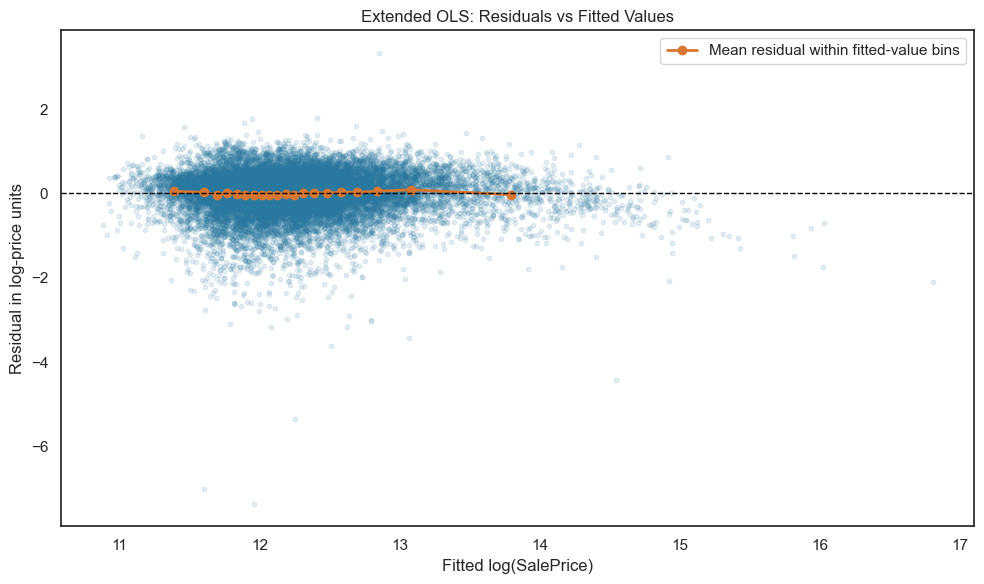

In [65]:
residual_review = pd.DataFrame({
    "Fitted_LogPrice": ols_extended.fittedvalues,
    "Residual": ols_extended.resid
})

residual_review["Fitted_Group"] = pd.qcut(
    residual_review["Fitted_LogPrice"],
    q=20,
    duplicates="drop"
)

residual_bins = (
    residual_review.groupby("Fitted_Group", observed=True)
    .agg(
        Fitted_LogPrice=("Fitted_LogPrice", "mean"),
        Mean_Residual=("Residual", "mean")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    residual_review["Fitted_LogPrice"],
    residual_review["Residual"],
    s=10,
    alpha=0.12,
    color="#2878A0"
)

ax.plot(
    residual_bins["Fitted_LogPrice"],
    residual_bins["Mean_Residual"],
    marker="o",
    color="#D97732",
    linewidth=2,
    label="Mean residual within fitted-value bins"
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set(
    title="Extended OLS: Residuals vs Fitted Values",
    xlabel="Fitted log(SalePrice)",
    ylabel="Residual in log-price units"
)

ax.legend()
plt.tight_layout()
plt.show()

In [66]:
influence = ols_extended.get_influence()

influence_review = ols_data[
    [
        "UniqueID", "ParcelID", "PropertyCity",
        "SaleDate", "SalePrice", "Bedrooms",
        "FullBath", "HalfBath", "Acreage",
        "AgeAtSale", "SoldAsVacant"
    ]
].copy()

influence_review["Fitted_LogPrice"] = ols_extended.fittedvalues
influence_review["Residual"] = ols_extended.resid
influence_review["Leverage"] = influence.hat_matrix_diag
influence_review["Cooks_Distance"] = influence.cooks_distance[0]

influence_review["Actual_to_Fitted_Ratio"] = np.exp(
    influence_review["Residual"]
)

print("Top 10 records by Cook's distance")

display(
    influence_review
    .sort_values("Cooks_Distance", ascending=False)
    .head(10)
    .round(4)
)

Top 10 records by Cook's distance


,UniqueID,ParcelID,PropertyCity,SaleDate,SalePrice,Bedrooms,FullBath,HalfBath,Acreage,AgeAtSale,SoldAsVacant,Fitted_LogPrice,Residual,Leverage,Cooks_Distance,Actual_to_Fitted_Ratio
1344,245,041 11 0 011.00,NASHVILLE,2013-01-04,100.0,2.0,1.0,0.0,0.78,55.0,No,11.6066,-7.0014,0.0015,0.0093,0.0009
12728,21203,081 11 0 574.00,NASHVILLE,2014-09-22,25000.0,7.0,7.0,0.0,0.25,0.0,No,14.5462,-4.4196,0.0036,0.0090,0.0120
7514,8894,070 05 0 031.00,NASHVILLE,2013-10-15,100.0,2.0,1.0,0.0,0.39,93.0,No,11.9634,-7.3583,0.0013,0.0088,0.0006
1416,2058,042 02 0 001.00,NASHVILLE,2013-04-17,18000.0,3.0,2.0,0.0,3.23,0.0,Yes,12.7964,-2.9982,0.0035,0.0040,0.0499
22326,3568,094 12 0 025.00,NASHVILLE,2013-05-23,7250.0,3.0,2.0,0.0,0.67,0.0,Yes,12.5147,-3.6259,0.0023,0.0038,0.0266
38031,50281,132 06 0 038.00,NASHVILLE,2016-06-07,2438500.0,11.0,9.0,2.0,8.12,46.0,No,16.8076,-2.1007,0.0067,0.0038,0.1224
32314,22405,117 09 0 057.00,NASHVILLE,2014-10-20,1600000.0,10.0,10.0,0.0,1.33,66.0,No,16.0259,-1.7404,0.0069,0.0027,0.1755
11802,46857,080 04 0 083.00,NASHVILLE,2016-04-29,16750.0,5.0,2.0,0.0,0.17,0.0,Yes,12.6412,-2.9151,0.0025,0.0027,0.0542
39826,17359,136 11 0 005.00,NASHVILLE,2014-06-27,1000.0,3.0,2.0,0.0,0.48,46.0,No,12.2549,-5.3472,0.0007,0.0026,0.0048
19019,19742,091 08 0 057.00,NASHVILLE,2014-08-12,12750.0,3.0,2.0,1.0,0.17,0.0,Yes,12.6274,-3.1741,0.0017,0.0022,0.0418


In [67]:
ols_vacancy_data = ols_data.copy()

ols_vacancy_data["SoldAsVacant"] = (
    ols_vacancy_data["SoldAsVacant"]
    .astype("string")
    .str.strip()
)

assert ols_vacancy_data["SoldAsVacant"].isin(["No", "Yes"]).all(), (
    "Review missing or unexpected SoldAsVacant values."
)

ols_vacancy_data["SoldAsVacant"] = (
    ols_vacancy_data["SoldAsVacant"].astype(str)
)

formula_vacancy = (
    formula_extended
    + " + C(SoldAsVacant, Treatment(reference='No'))"
)

ols_with_vacancy = smf.ols(
    formula_vacancy,
    data=ols_vacancy_data,
    missing="raise"
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": pd.factorize(ols_vacancy_data["ParcelID"])[0]
    }
)

vacancy_term = "C(SoldAsVacant, Treatment(reference='No'))[T.Yes]"
comparison_rows = []

for name, fitted in [
    ("Before vacancy control", ols_extended),
    ("After vacancy control", ols_with_vacancy)
]:
    intervals = fitted.conf_int()

    for term in [
        "Bedrooms", "FullBath", "HalfBath",
        "LogAcreage", vacancy_term
    ]:
        if term in fitted.params.index:
            comparison_rows.append({
                "Model": name,
                "Term": "SoldAsVacant: Yes vs No"
                if term == vacancy_term else term,
                "Coefficient": fitted.params[term],
                "CI_Lower": intervals.loc[term, 0],
                "CI_Upper": intervals.loc[term, 1]
            })

print("SoldAsVacant counts in the model sample")
display(ols_vacancy_data["SoldAsVacant"].value_counts())

print("Coefficient comparison")
display(pd.DataFrame(comparison_rows).round(4))

print("Model fit on the same sample")
display(pd.DataFrame({
    "Model": ["Before vacancy control", "After vacancy control"],
    "Records": [
        int(ols_extended.nobs),
        int(ols_with_vacancy.nobs)
    ],
    "Adjusted_R2_LogPrice": [
        ols_extended.rsquared_adj,
        ols_with_vacancy.rsquared_adj
    ]
}).round(4))

SoldAsVacant counts in the model sample


SoldAsVacant
No     20441
Yes       50
Name: count, dtype: int64

Coefficient comparison


,Model,Term,Coefficient,CI_Lower,CI_Upper
0,Before vacancy control,Bedrooms,0.0660,0.0515,0.0804
1,Before vacancy control,FullBath,0.3726,0.3598,0.3854
2,Before vacancy control,HalfBath,0.2801,0.2634,0.2968
3,Before vacancy control,LogAcreage,0.2167,0.2023,0.2310
4,After vacancy control,Bedrooms,0.0669,0.0526,0.0813
5,After vacancy control,FullBath,0.3716,0.3589,0.3842
6,After vacancy control,HalfBath,0.2785,0.2621,0.2950
7,After vacancy control,LogAcreage,0.2165,0.2025,0.2304
8,After vacancy control,SoldAsVacant: Yes vs No,-1.2635,-1.5610,-0.9661


Model fit on the same sample


,Model,Records,Adjusted_R2_LogPrice
0,Before vacancy control,20491,0.5601
1,After vacancy control,20491,0.5669


In [68]:
ols_categorical_data = ols_vacancy_data.copy()

ols_categorical_data["BedroomGroup"] = pd.cut(
    ols_categorical_data["Bedrooms"],
    bins=[-np.inf, 1, 2, 3, 4, 5, np.inf],
    labels=["0–1", "2", "3", "4", "5", "6+"]
)

ols_categorical_data["FullBathGroup"] = pd.cut(
    ols_categorical_data["FullBath"],
    bins=[-np.inf, 1, 2, 3, 4, np.inf],
    labels=["0–1", "2", "3", "4", "5+"]
)

ols_categorical_data["HalfBathGroup"] = pd.cut(
    ols_categorical_data["HalfBath"],
    bins=[-np.inf, 0, 1, np.inf],
    labels=["0", "1", "2+"]
)

formula_categorical = (
    "LogSalePrice ~ C(BedroomGroup, Treatment(reference='3'))"
    " + C(FullBathGroup, Treatment(reference='2'))"
    " + C(HalfBathGroup, Treatment(reference='0'))"
    " + LogAcreage"
    " + C(AgeGroup, Treatment(reference='21–40'))"
    " + C(PropertyCity) + C(SaleYear) + C(SaleMonth)"
    " + C(SoldAsVacant, Treatment(reference='No'))"
)

ols_categorical = smf.ols(
    formula_categorical,
    data=ols_categorical_data,
    missing="raise"
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": pd.factorize(ols_categorical_data["ParcelID"])[0]
    }
)

bedroom_comparison_rows = []

for name, fitted, term in [
    ("Linear counts", ols_with_vacancy, "Bedrooms"),
    (
        "Categorical counts",
        ols_categorical,
        "C(BedroomGroup, Treatment(reference='3'))[T.4]"
    )
]:
    interval = fitted.conf_int().loc[term]

    bedroom_comparison_rows.append({
        "Model": name,
        "Records": int(fitted.nobs),
        "Adjusted_R2_LogPrice": fitted.rsquared_adj,
        "4BR_vs_3BR_Percent": 100 * np.expm1(fitted.params[term]),
        "CI_Lower_Percent": 100 * np.expm1(interval.iloc[0]),
        "CI_Upper_Percent": 100 * np.expm1(interval.iloc[1])
    })

display(pd.DataFrame(bedroom_comparison_rows).round(3))

print("Records per category")
for column in ["BedroomGroup", "FullBathGroup", "HalfBathGroup"]:
    display(
        ols_categorical_data[column]
        .value_counts(sort=False)
        .rename("Records")
        .to_frame()
    )

,Model,Records,Adjusted_R2_LogPrice,4BR_vs_3BR_Percent,CI_Lower_Percent,CI_Upper_Percent
0,Linear counts,20491,0.567,6.924,5.399,8.471
1,Categorical counts,20491,0.571,9.375,6.975,11.829


Records per category


,Records
BedroomGroup,
0–1,73
2,4349
3,11609
4,3647
5,675
6+,138


,Records
FullBathGroup,
0–1,8648
2,8051
3,2786
4,664
5+,342


,Records
HalfBathGroup,
0,15216
1,5014
2+,261
